In [7]:
import pandas as pd
import numpy as np
from helpers import get_feature_importance, bin_count_pipe, new_col_pipe, target_enc_pipe, outliers_pipe
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from joblib import dump, load

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report
from category_encoders import CountEncoder
from category_encoders.target_encoder import TargetEncoder
seed = 42

In [2]:
# Загрузим данные и результаты baseline
data = pd.read_csv('bank.csv')
result_cross_val_baseline = load('result_cross_val_baseline.joblib')
result_test_baseline = load('result_test_baseline.joblib')

### Feature engineering
Далее мы будем создавать новые, либо изменять старые признаки для улучшения метрик моделей.
Для обучения моделей на измененных признаках - будем использовать в качестве основы пайплайн с предыдущего шага (baseline) 

## Бинаризация и частотное кодирование
Бинаризуем признак age (удалив оригинальный столбец) и применим частотное кодирование к признаку day.
При частотном кодировании значения признака заменяются на частоту встречаемости признака в датасете

In [8]:
df = data.copy()
# бинаризируем признак age
age_bins = [0,25,35,45,55,65,1000]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df['age'] = pd.cut(df['age'], bins=age_bins, labels = age_labels)

df['day'] = df['day'].astype(str)

In [4]:
result_cross_val_bin_count, result_test_bin_count, models_bin_count = bin_count_pipe(df)

In [5]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val_bin_count)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test_bin_count)
print('')
print('Сравнение полученного результата с baseline')
print('')
display(result_test_bin_count - result_test_baseline)


Результаты на кросс-валидации



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.9041 ± 0.0045,0.8269 ± 0.0082,0.8292 ± 0.0081,0.7993 ± 0.0148,0.8139 ± 0.0095
RandomForest,0.9133 ± 0.0037,0.8458 ± 0.0035,0.8178 ± 0.0029,0.8679 ± 0.0114,0.8421 ± 0.0047
XGBoost,0.915 ± 0.0061,0.846 ± 0.0069,0.8219 ± 0.0045,0.8617 ± 0.0138,0.8413 ± 0.0079



Результаты на тестовой выборке



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.908094,0.824004,0.821878,0.802457,0.812052
RandomForest,0.916035,0.854456,0.821773,0.884688,0.852071
XGBoost,0.920516,0.848634,0.824910,0.863894,0.843952



Сравнение полученного результата с baseline



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.000797,-0.001343,-0.005573,0.004726,-0.000268
RandomForest,-0.003293,-0.007165,-0.009936,-0.002836,-0.006640
XGBoost,-0.005210,-0.015674,-0.016102,-0.016068,-0.016094


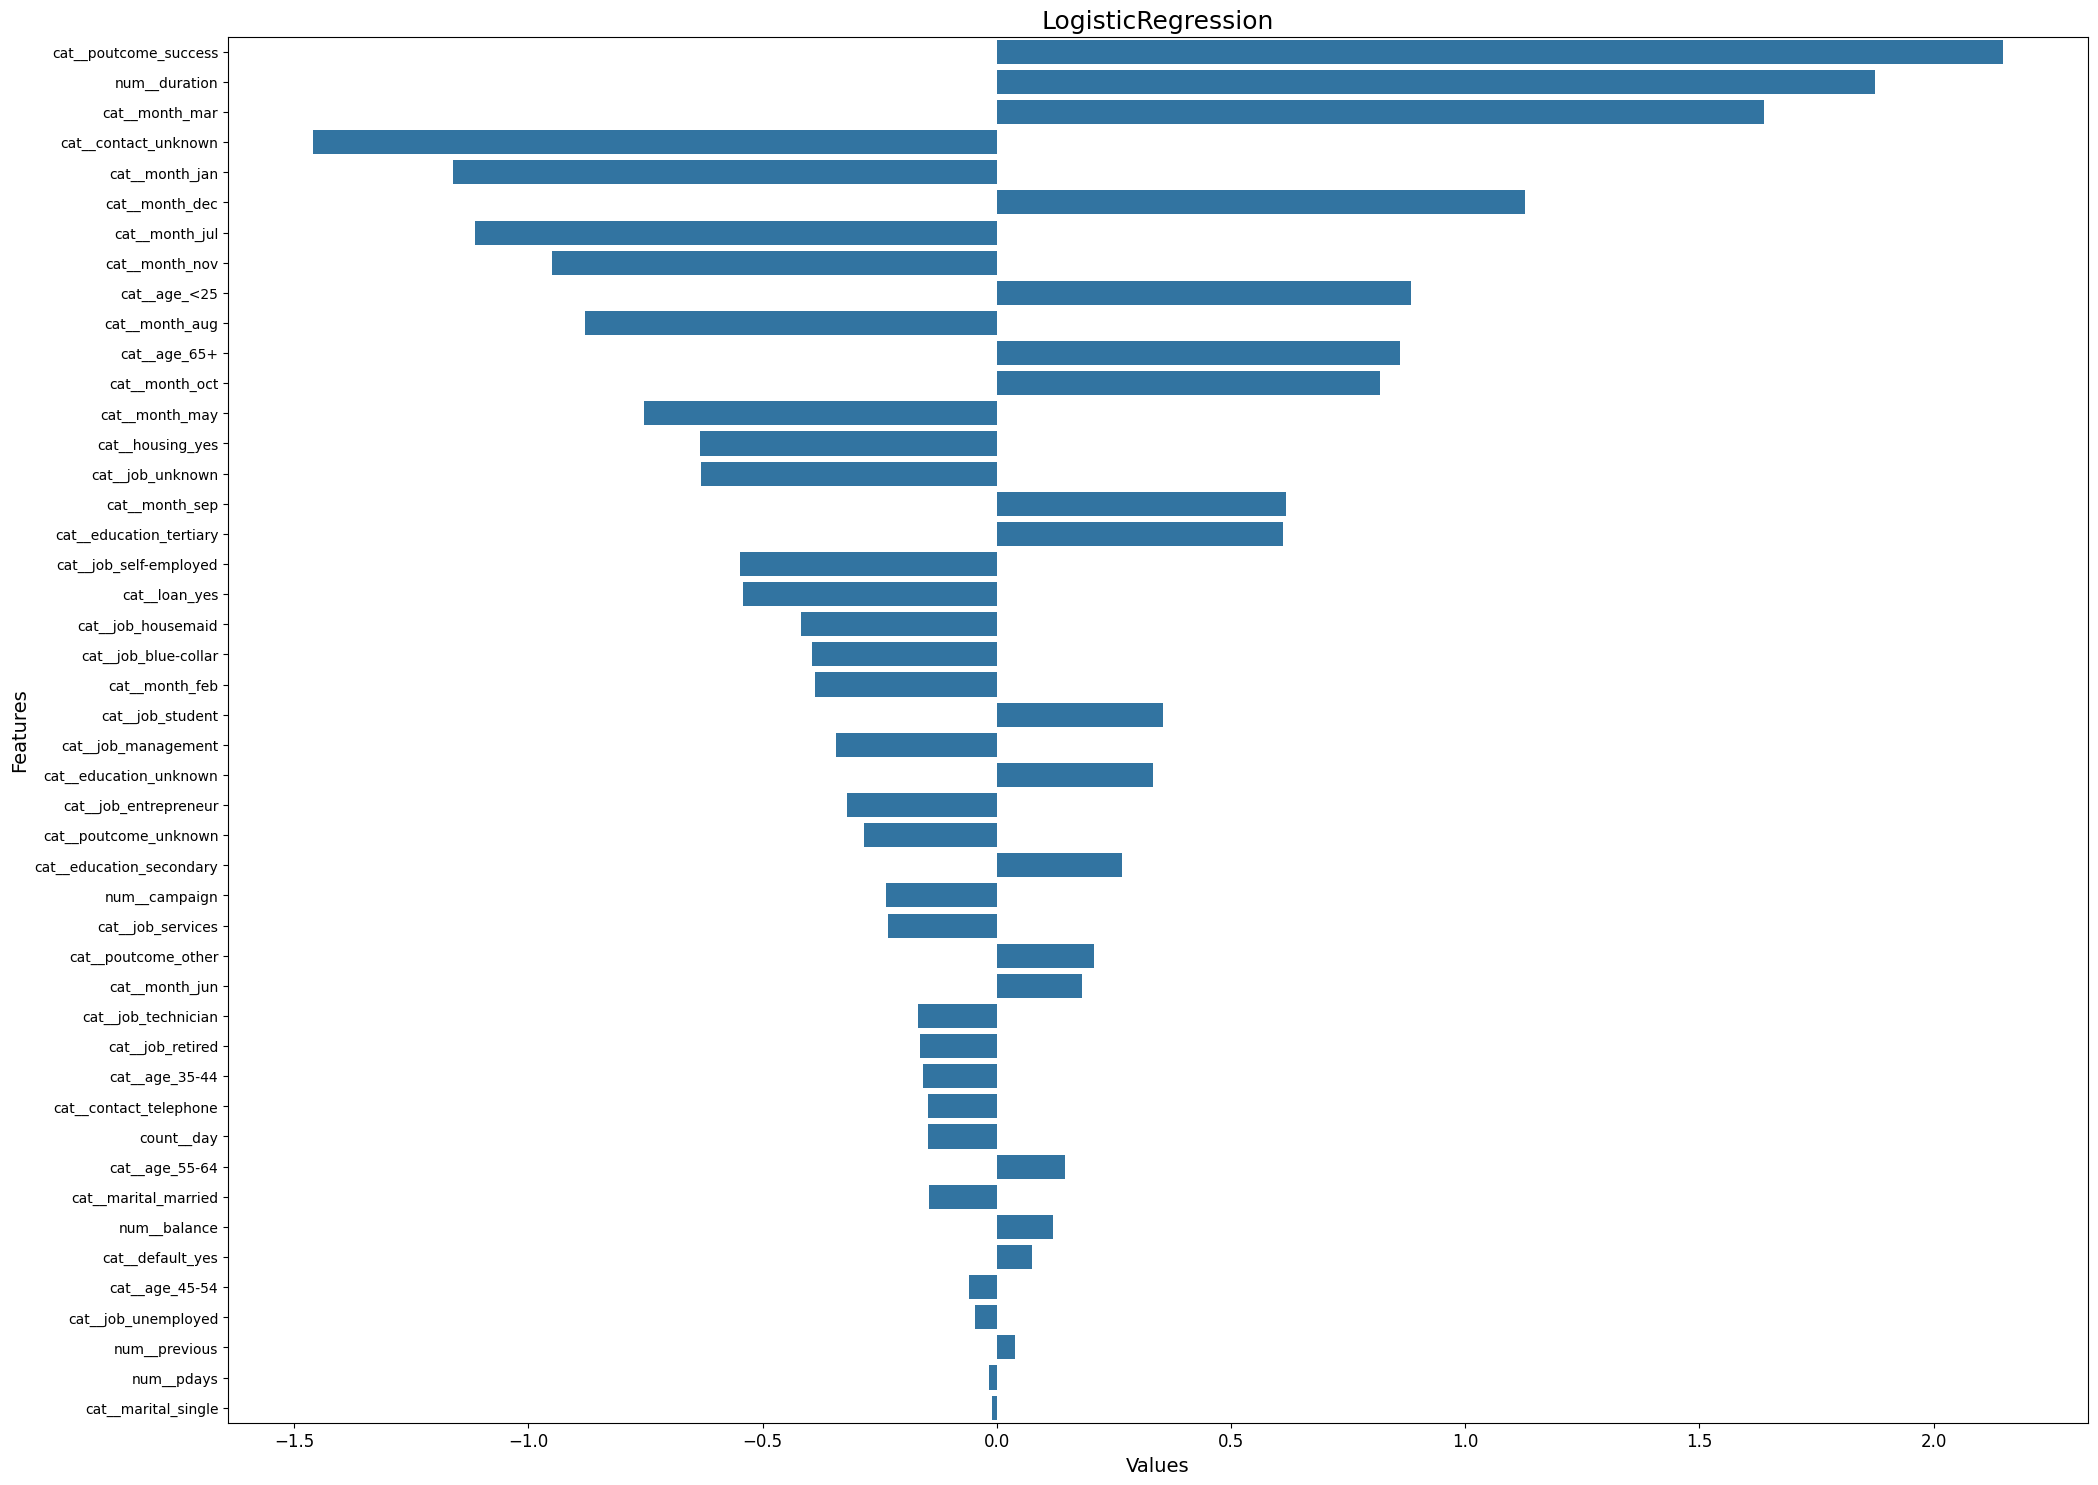

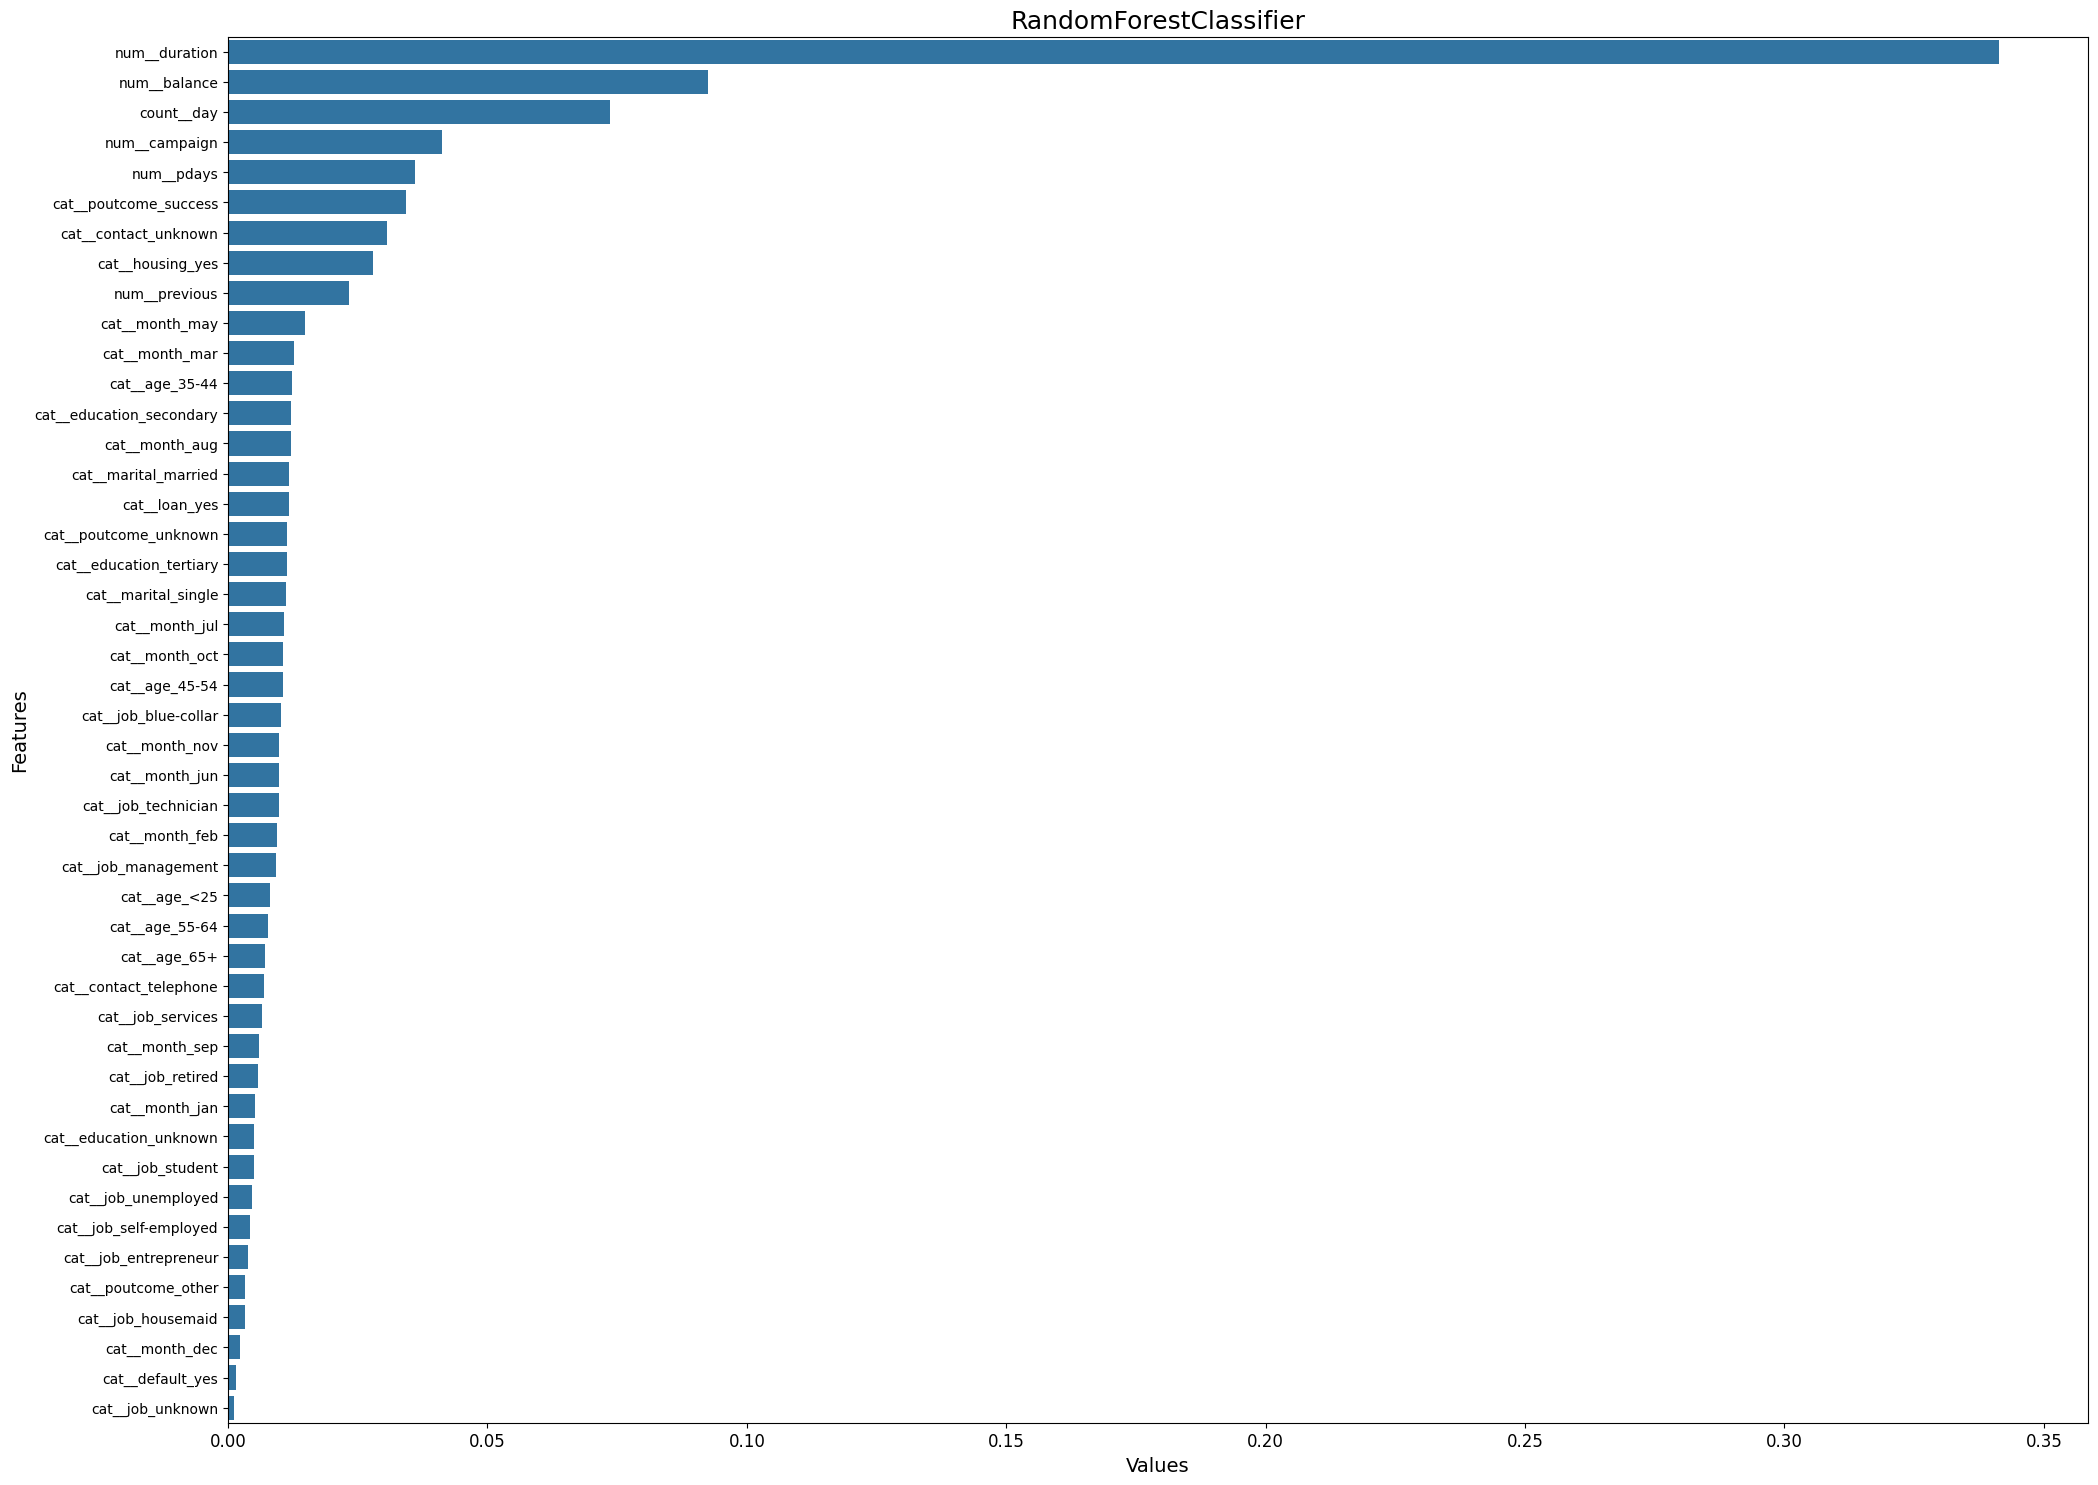

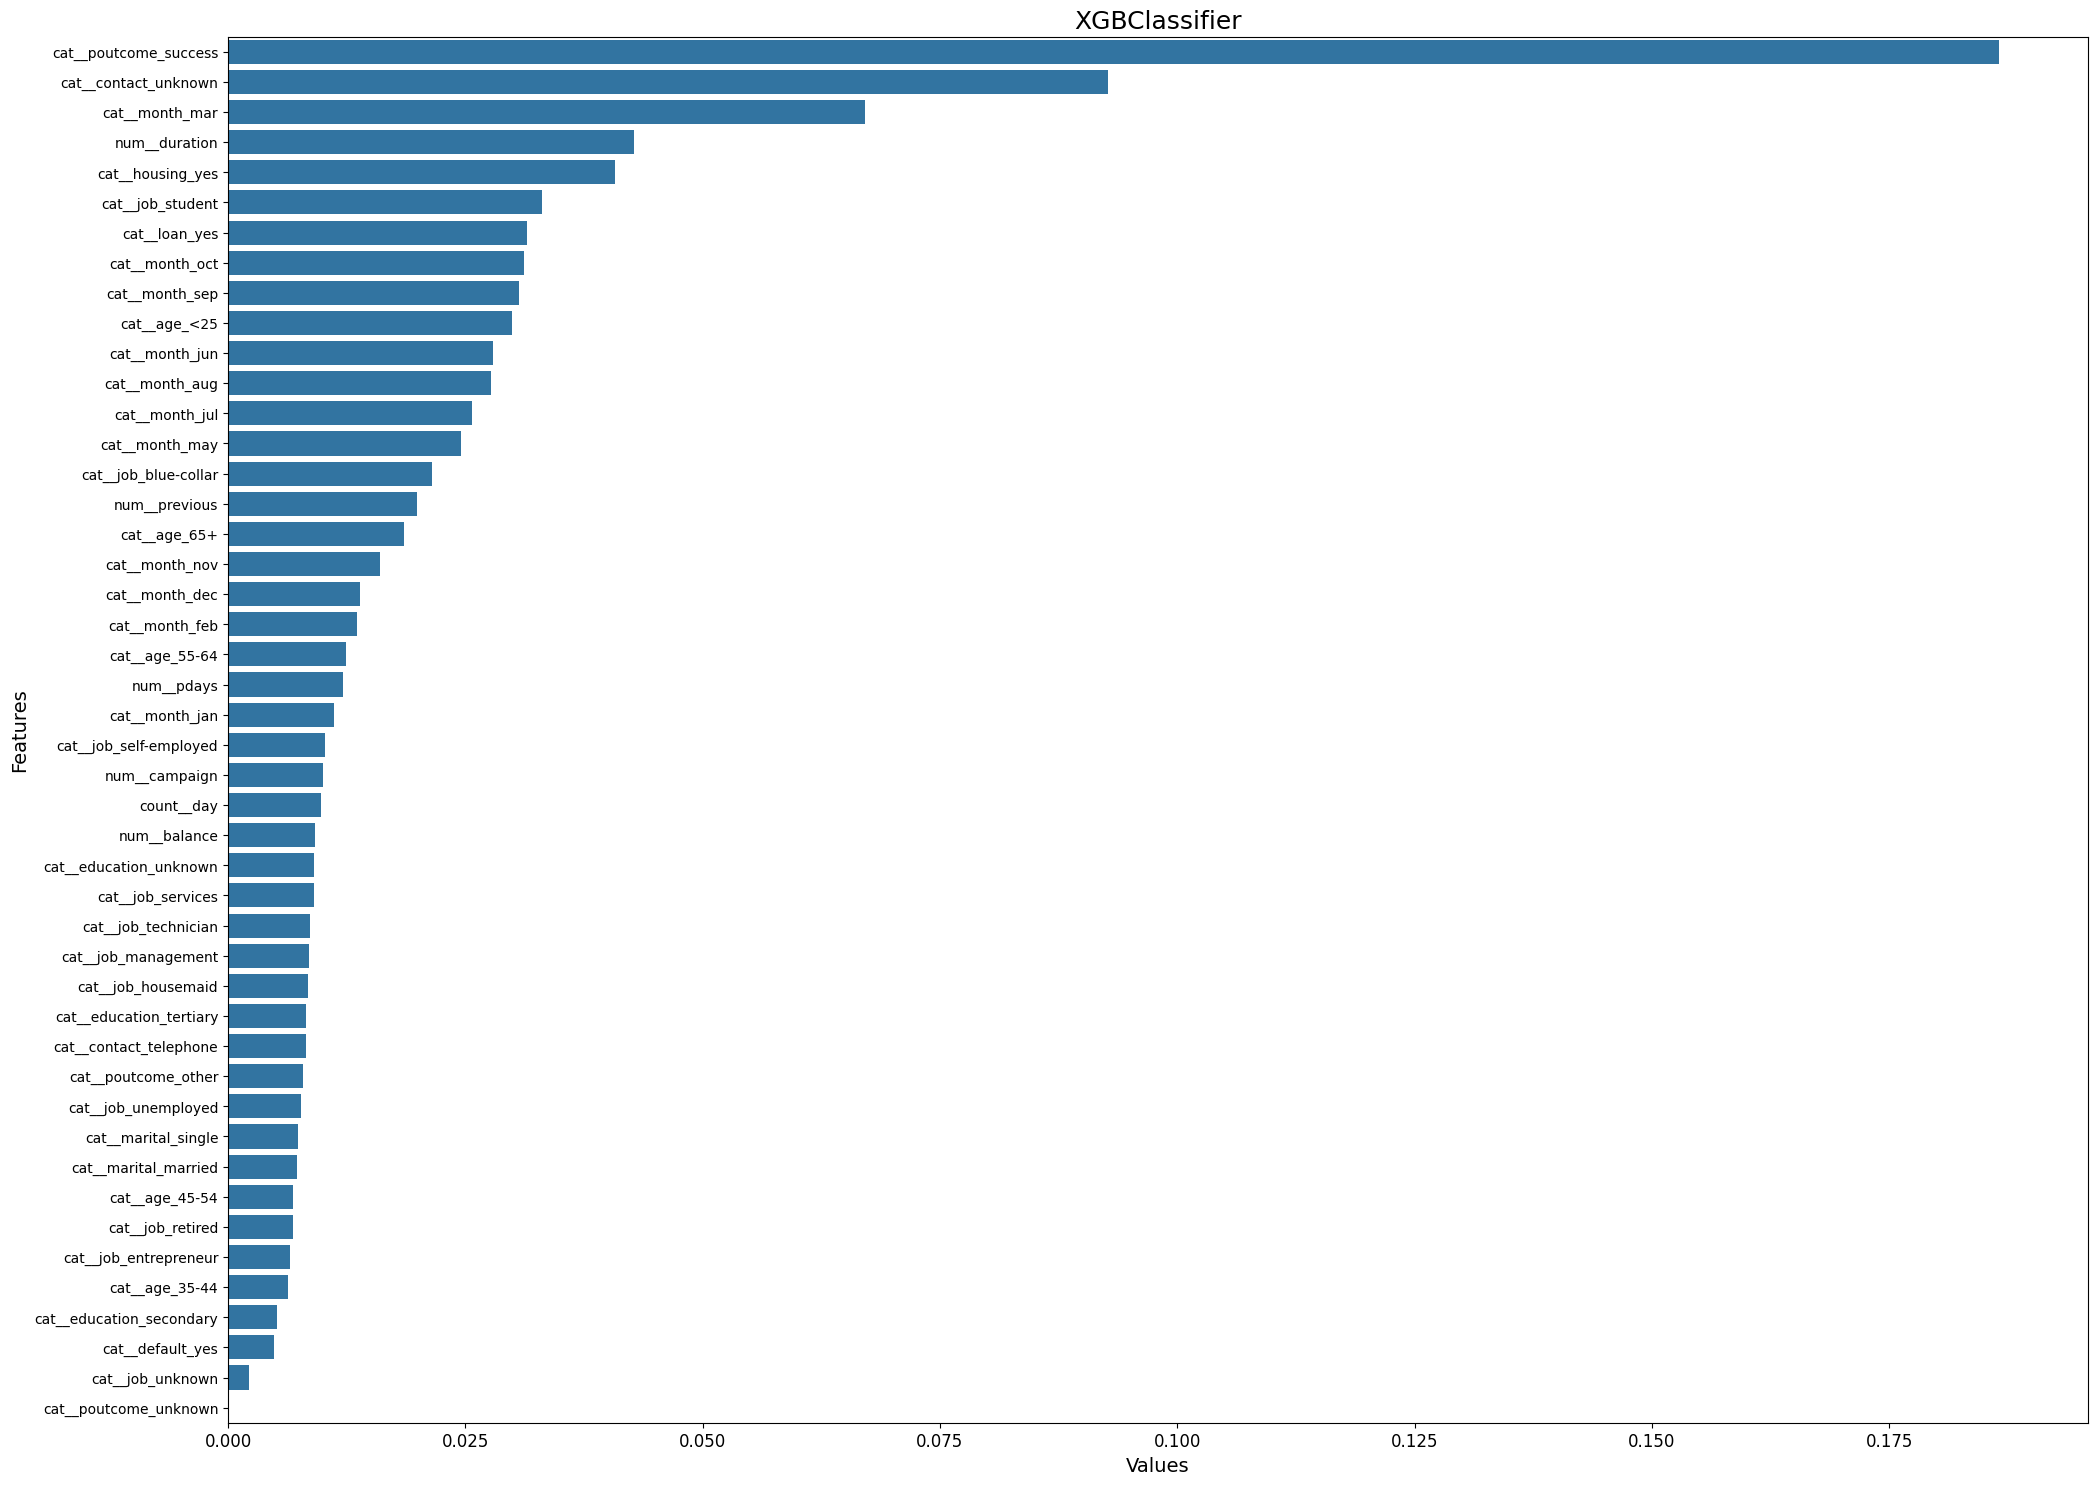

In [6]:
get_feature_importance(models_bin_count)

## Новые колонки

Создадим ряд новых колонок

In [3]:
df = data.copy()
# Были контакты или нет
df['ever_prev'] = (df['previous'] > 0).astype(int) 

# Бинаризируем признак pdays
def pdays_bucket(v):
   if v == -1:
       return 'never'
   if v <= 30:
       return 'recent'
   if v <= 60 and v > 30:
       return 'medium'
   return 'old'

df['pdays_bucket'] = df['pdays'].apply(pdays_bucket)

# Флаги для выбросов по колонкам balance, duration, campaign
df['high_balance'] = (df['balance'] > df['balance'].quantile(0.99)).astype(int)
df['long_call'] = (df['duration'] > df['duration'].quantile(0.99)).astype(int)
df['many_contacts'] = (df['campaign'] > df['campaign'].quantile(0.95)).astype(int)

# Попробуем применить простое мат.преобразование к колонкам age и balance
df['age_balance'] = df['age'] * df['balance']

In [4]:
result_cross_val_new_col, result_test_new_col, list_of_models_new_col = new_col_pipe(df)

In [5]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val_new_col)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test_new_col)
print('')
print('Сравнение полученного результата с baseline')
print('')
display(result_test_new_col - result_test_baseline)


Результаты на кросс-валидации



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.9022 ± 0.004,0.8254 ± 0.0084,0.8297 ± 0.0052,0.7946 ± 0.0187,0.8117 ± 0.0106
RandomForest,0.9169 ± 0.0048,0.846 ± 0.0068,0.8172 ± 0.0046,0.8695 ± 0.0116,0.8425 ± 0.0076
XGBoost,0.921 ± 0.0059,0.8522 ± 0.0069,0.8273 ± 0.0066,0.8695 ± 0.0126,0.8479 ± 0.0077



Результаты на тестовой выборке



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.906623,0.826243,0.826511,0.801512,0.813820
RandomForest,0.918617,0.857591,0.825132,0.887524,0.855191
XGBoost,0.923292,0.866099,0.840970,0.884688,0.862275



Сравнение полученного результата с baseline



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,-0.000674,0.000896,-0.000940,0.003781,0.001500
RandomForest,-0.000711,-0.004030,-0.006578,0.000000,-0.003519
XGBoost,-0.002434,0.001791,-0.000041,0.004726,0.002229


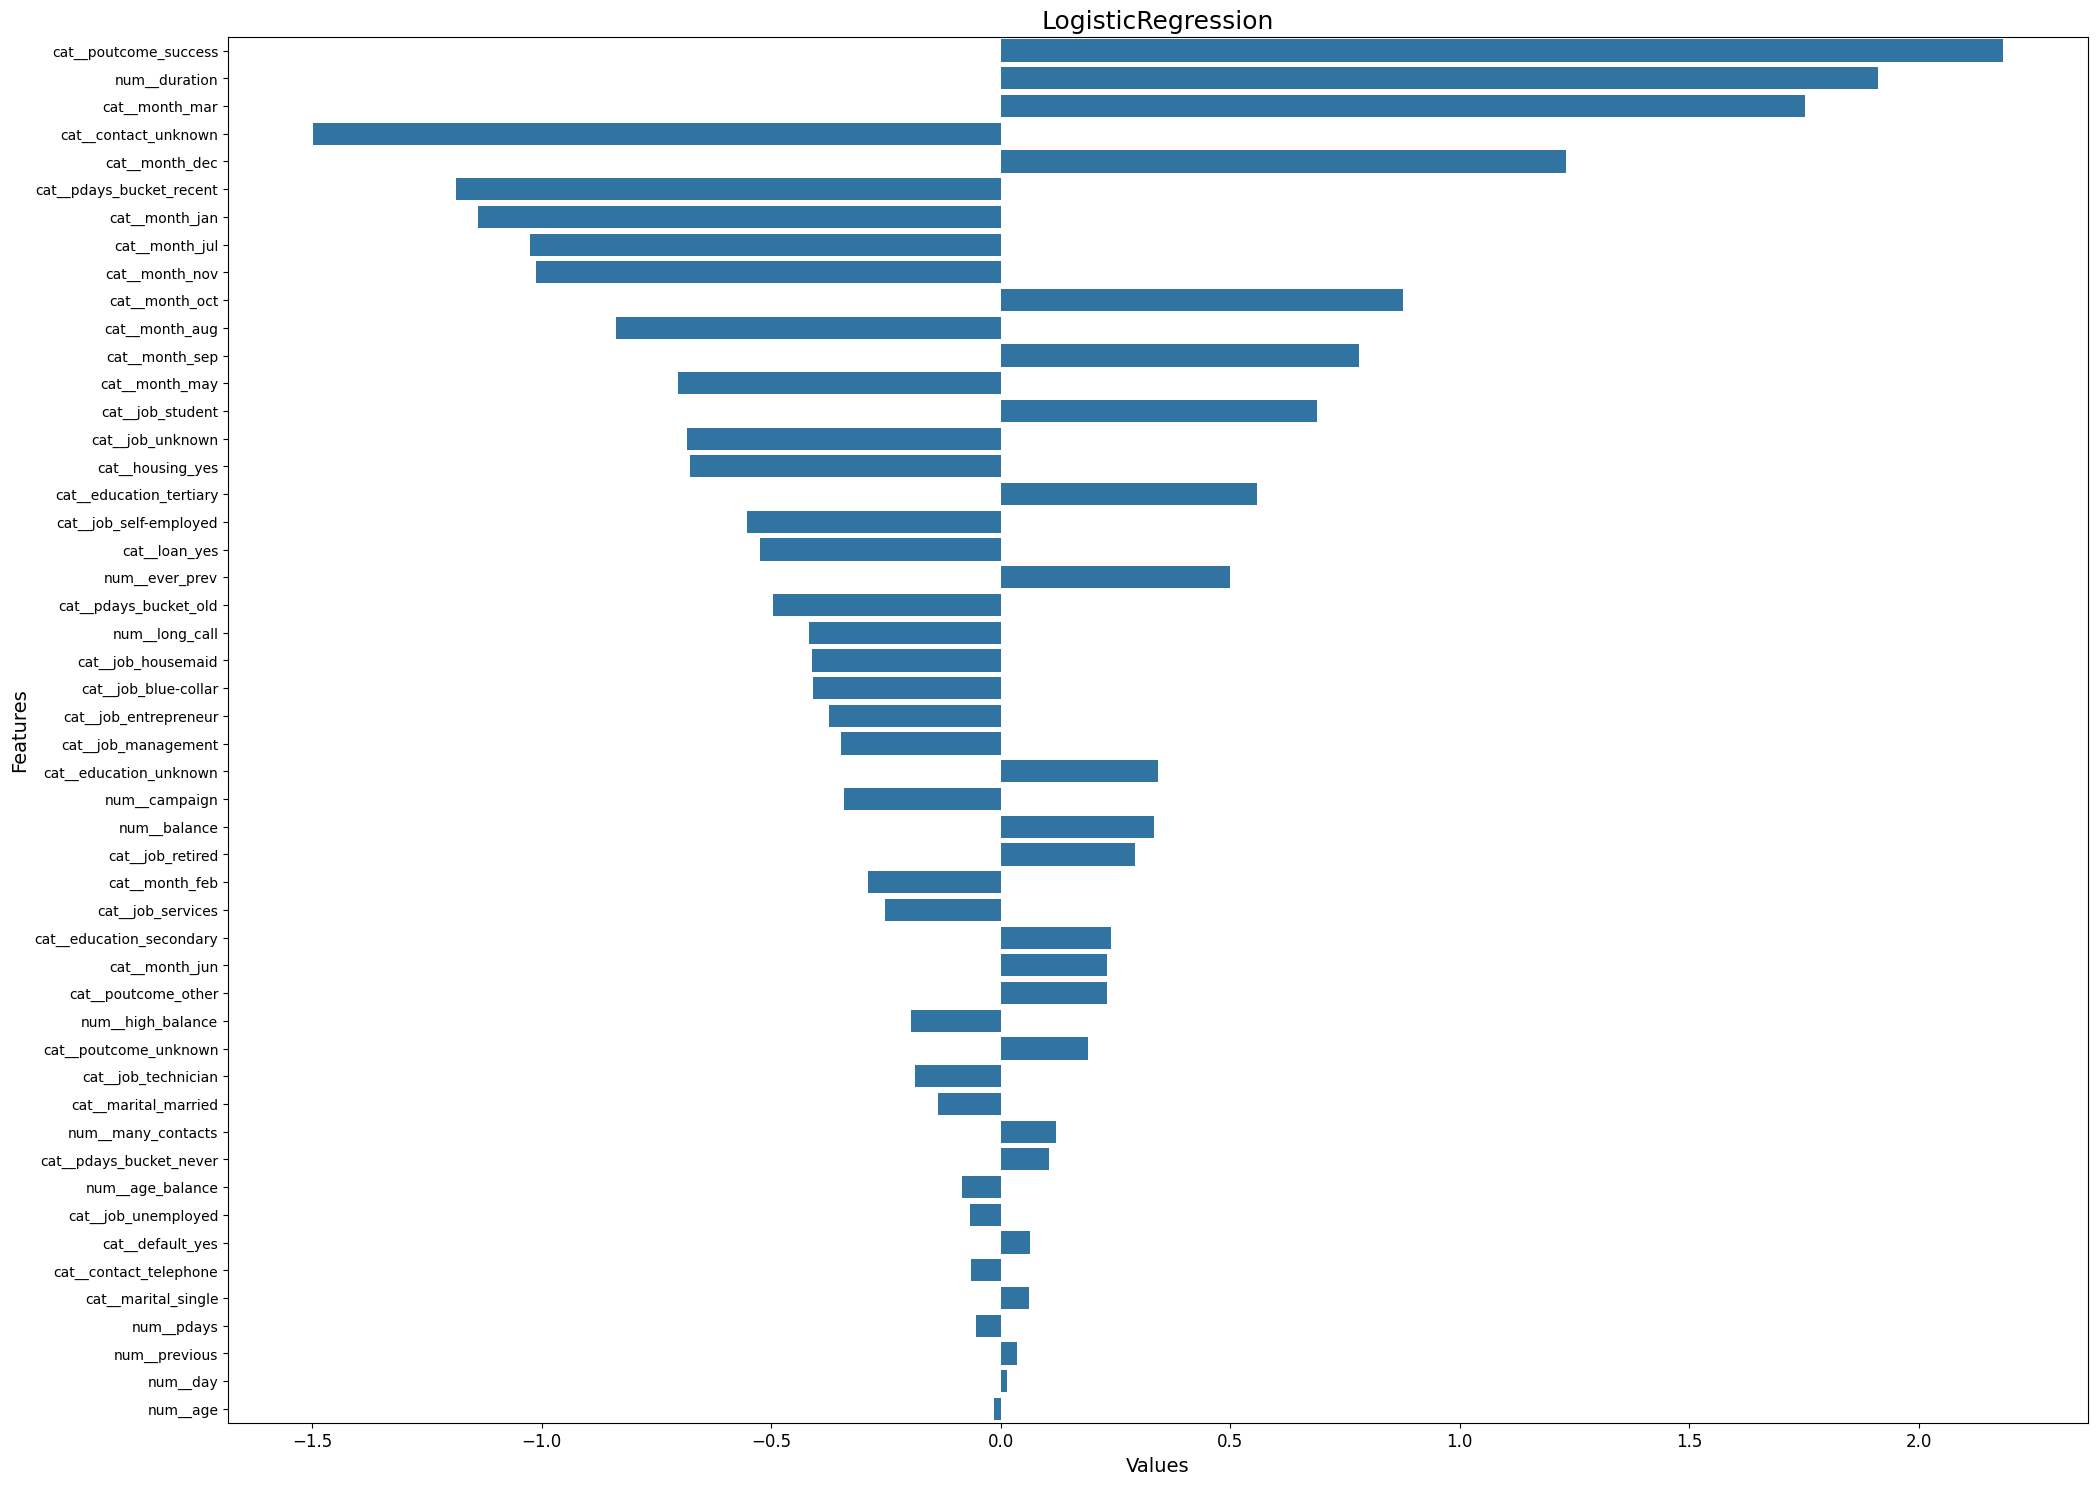

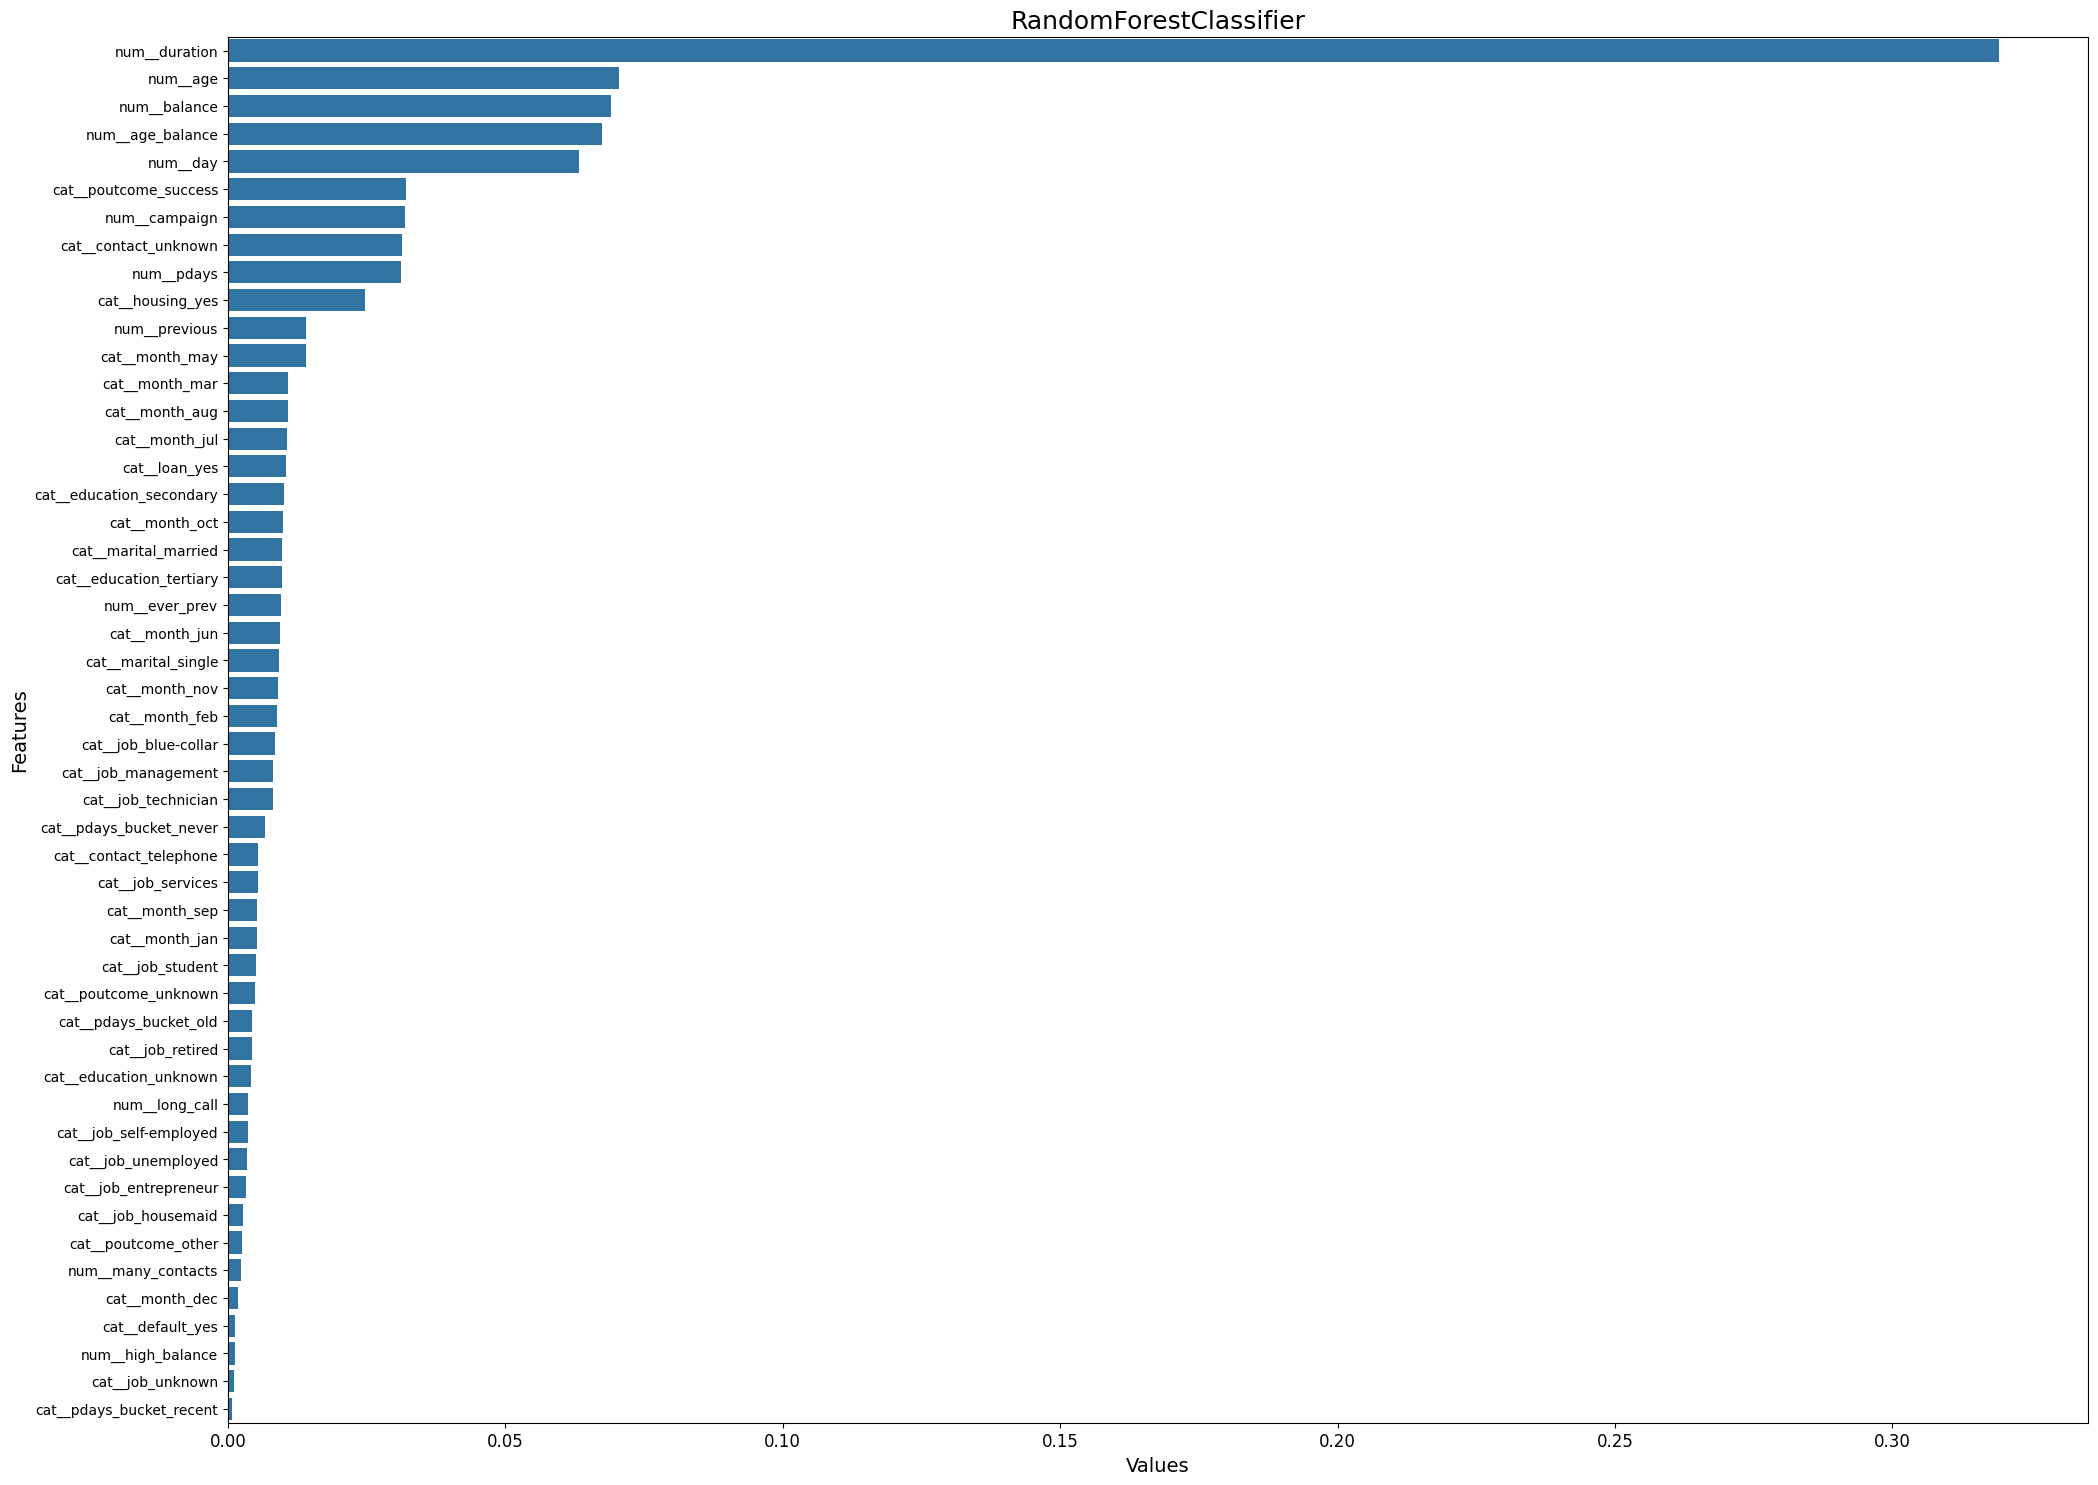

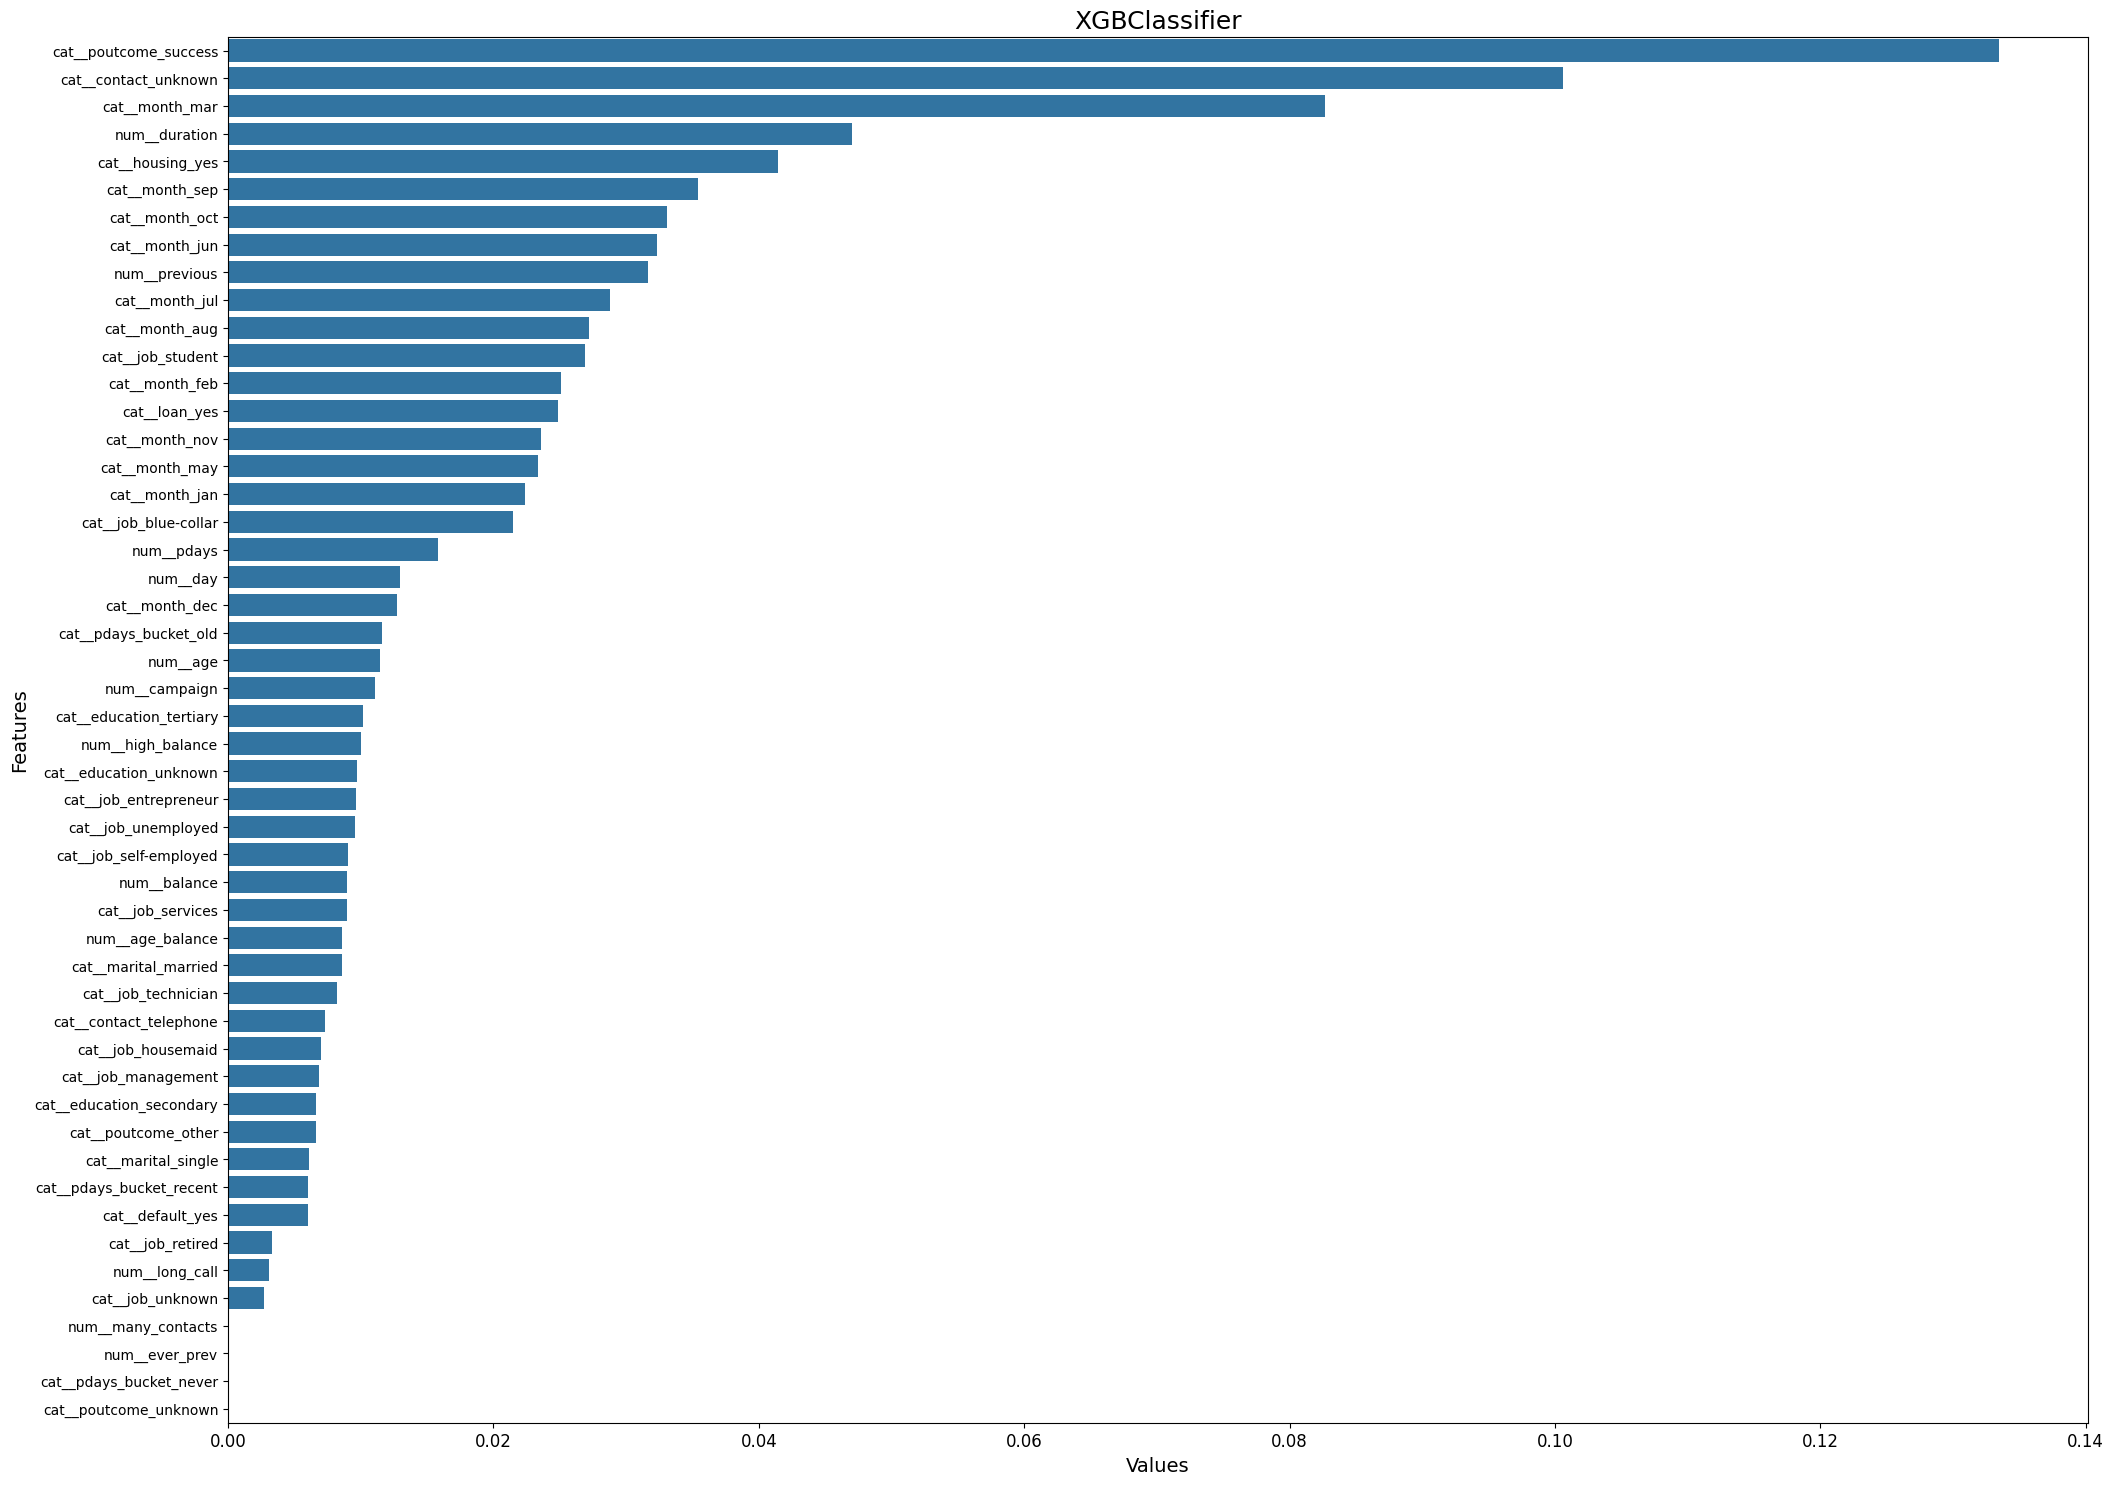

In [6]:
get_feature_importance(list_of_models_new_col)

## Лог преобразования
Прологарифмируем колонки balance, duration, pdays распределение которых сильно скошено вправо

In [8]:
df = data.copy()
df['log_balance'] = np.log1p(df['balance'].clip(lower=0))
df['log_duration'] = np.log1p(df['duration'].clip(lower=0))
df['log_pdays'] = np.log1p(df['pdays'].clip(lower=0))

df = df.drop(columns=['balance', 'duration', 'pdays'])

In [10]:
df.head(5)

,age,job,marital,education,default,housing,loan,contact,day,month,campaign,previous,poutcome,deposit,log_balance,log_duration,log_pdays
0,59,admin.,married,secondary,no,yes,no,unknown,5,may,1,0,unknown,yes,7.759614,6.949856,0.0
1,56,admin.,married,secondary,no,no,no,unknown,5,may,1,0,unknown,yes,3.828641,7.291656,0.0
2,41,technician,married,secondary,no,yes,no,unknown,5,may,1,0,unknown,yes,7.147559,7.237059,0.0
3,55,services,married,secondary,no,yes,no,unknown,5,may,1,0,unknown,yes,7.814803,6.363028,0.0
4,54,admin.,married,tertiary,no,no,no,unknown,5,may,2,0,unknown,yes,5.220356,6.513230,0.0


In [15]:
result_cross_val_log, result_test_log, list_of_models_log = new_col_pipe(df)

In [16]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val_log)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test_log)
print('')
print('Сравнение полученного результата с baseline')
print('')
display(result_test_log - result_test_baseline)


Результаты на кросс-валидации



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.901 ± 0.0036,0.8229 ± 0.0063,0.807 ± 0.012,0.8237 ± 0.0104,0.8151 ± 0.0056
RandomForest,0.9163 ± 0.005,0.8506 ± 0.0072,0.8203 ± 0.0075,0.8769 ± 0.0108,0.8476 ± 0.0076
XGBoost,0.9199 ± 0.0045,0.8507 ± 0.0014,0.8276 ± 0.0046,0.8653 ± 0.0104,0.846 ± 0.0027



Результаты на тестовой выборке



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.903348,0.821317,0.805942,0.820416,0.813115
RandomForest,0.918738,0.858039,0.822454,0.893195,0.856366
XGBoost,0.925548,0.863412,0.841962,0.876181,0.858731



Сравнение полученного результата с baseline



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,-0.003949,-0.004030,-0.021509,0.022684,0.000795
RandomForest,-0.000590,-0.003583,-0.009255,0.005671,-0.002344
XGBoost,-0.000179,-0.000896,0.000950,-0.003781,-0.001315


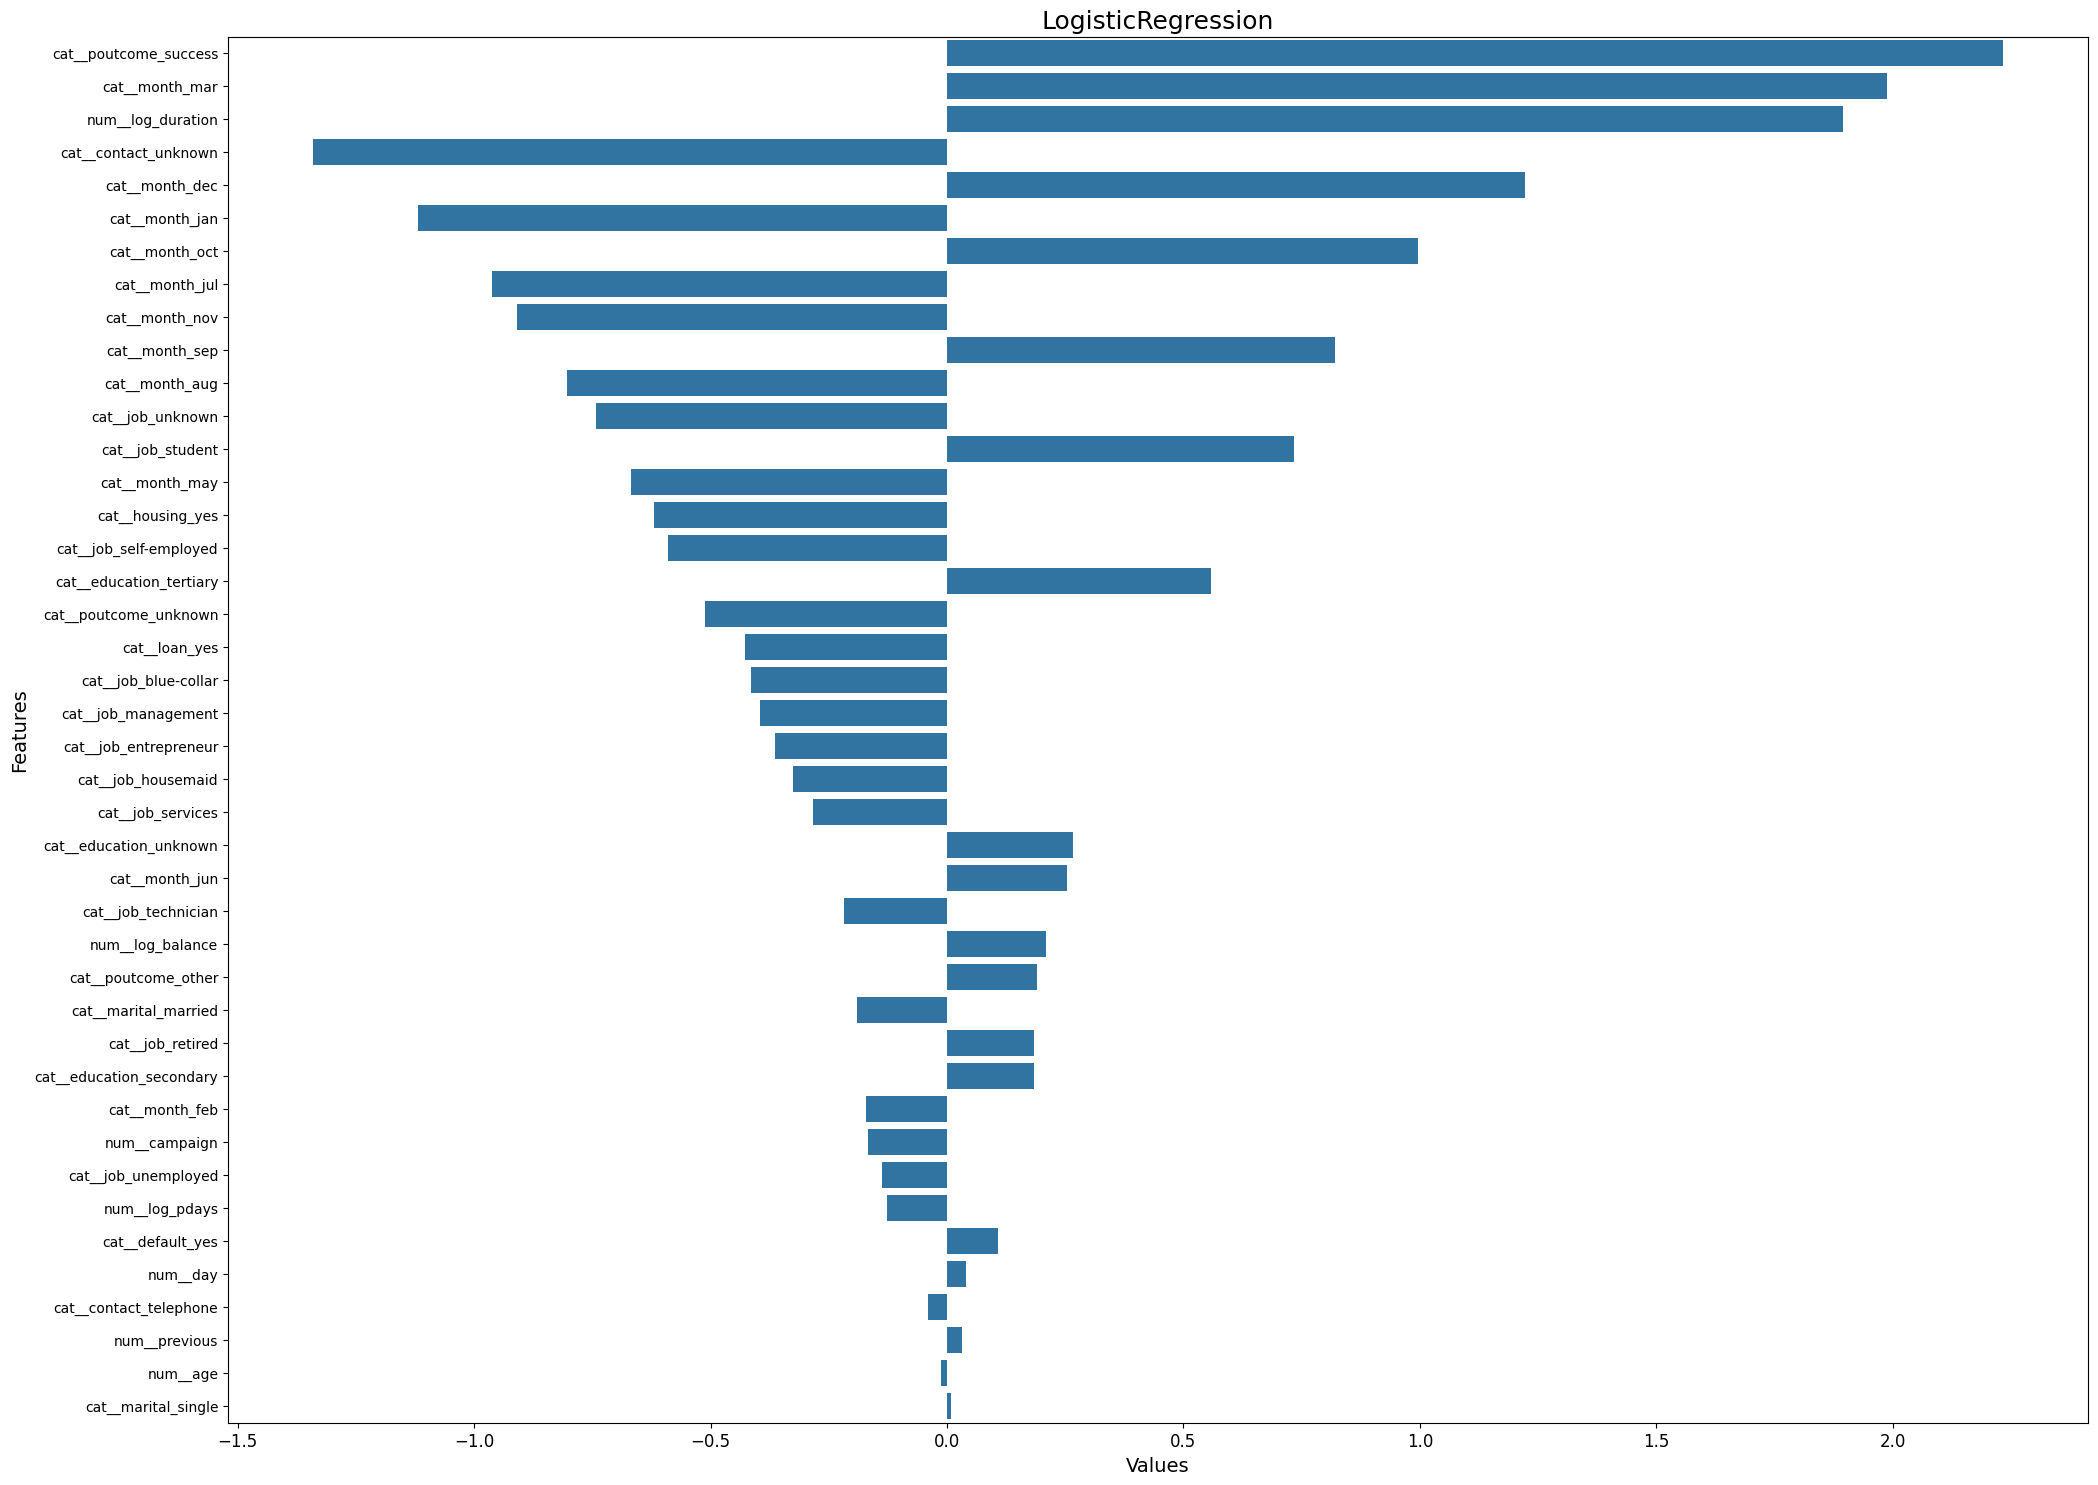

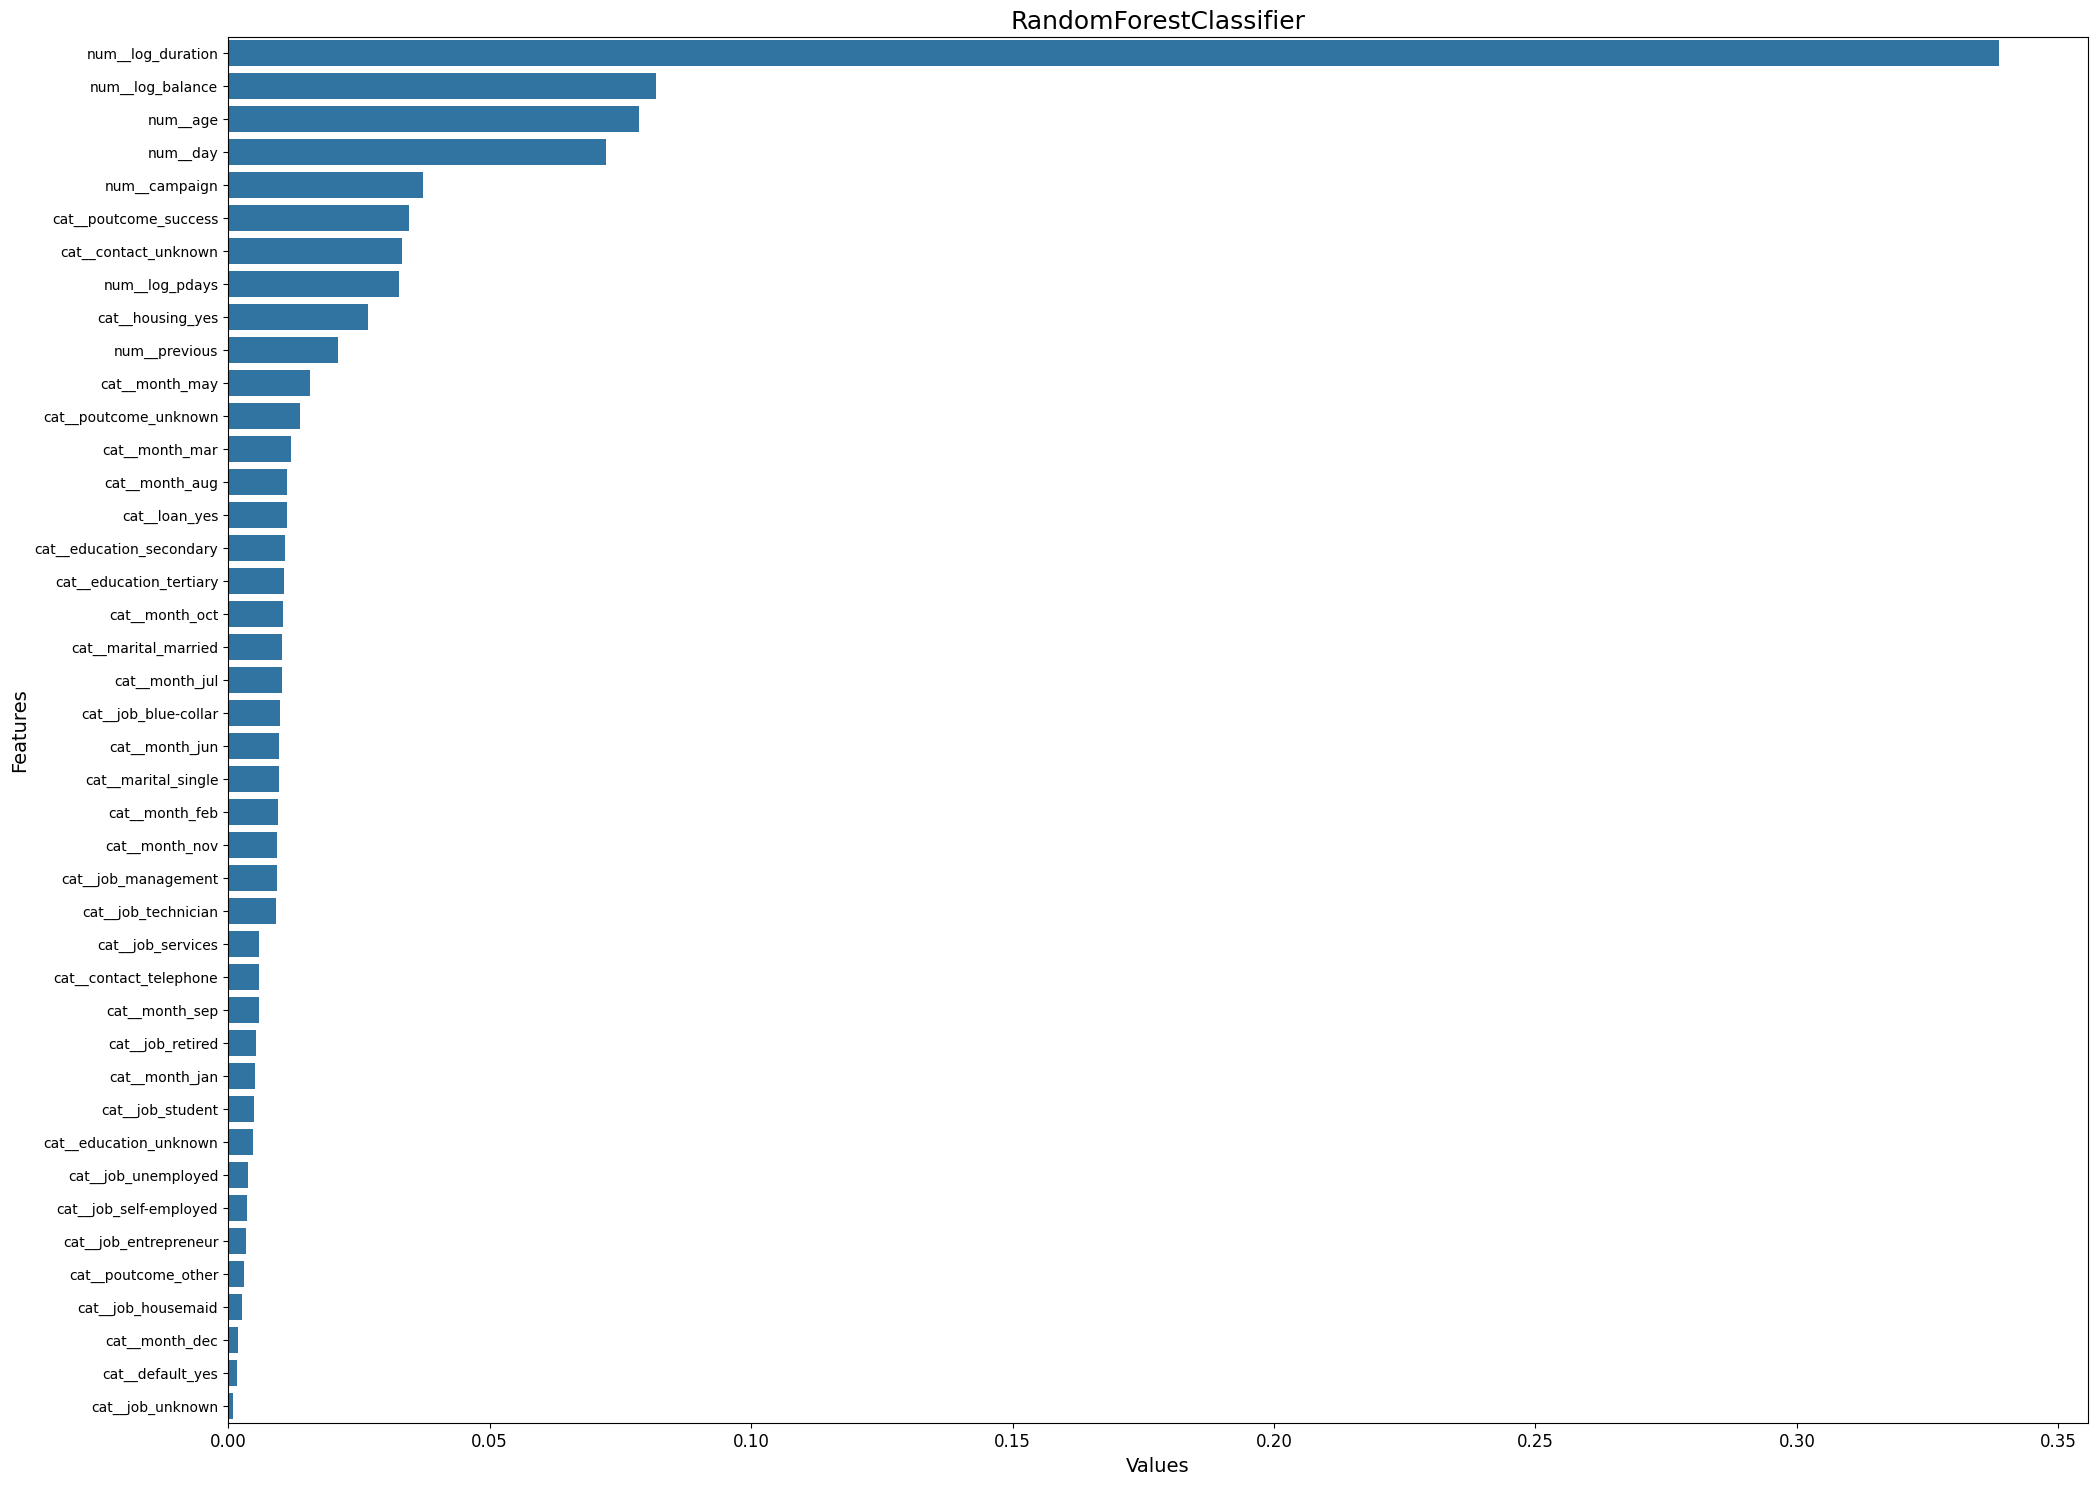

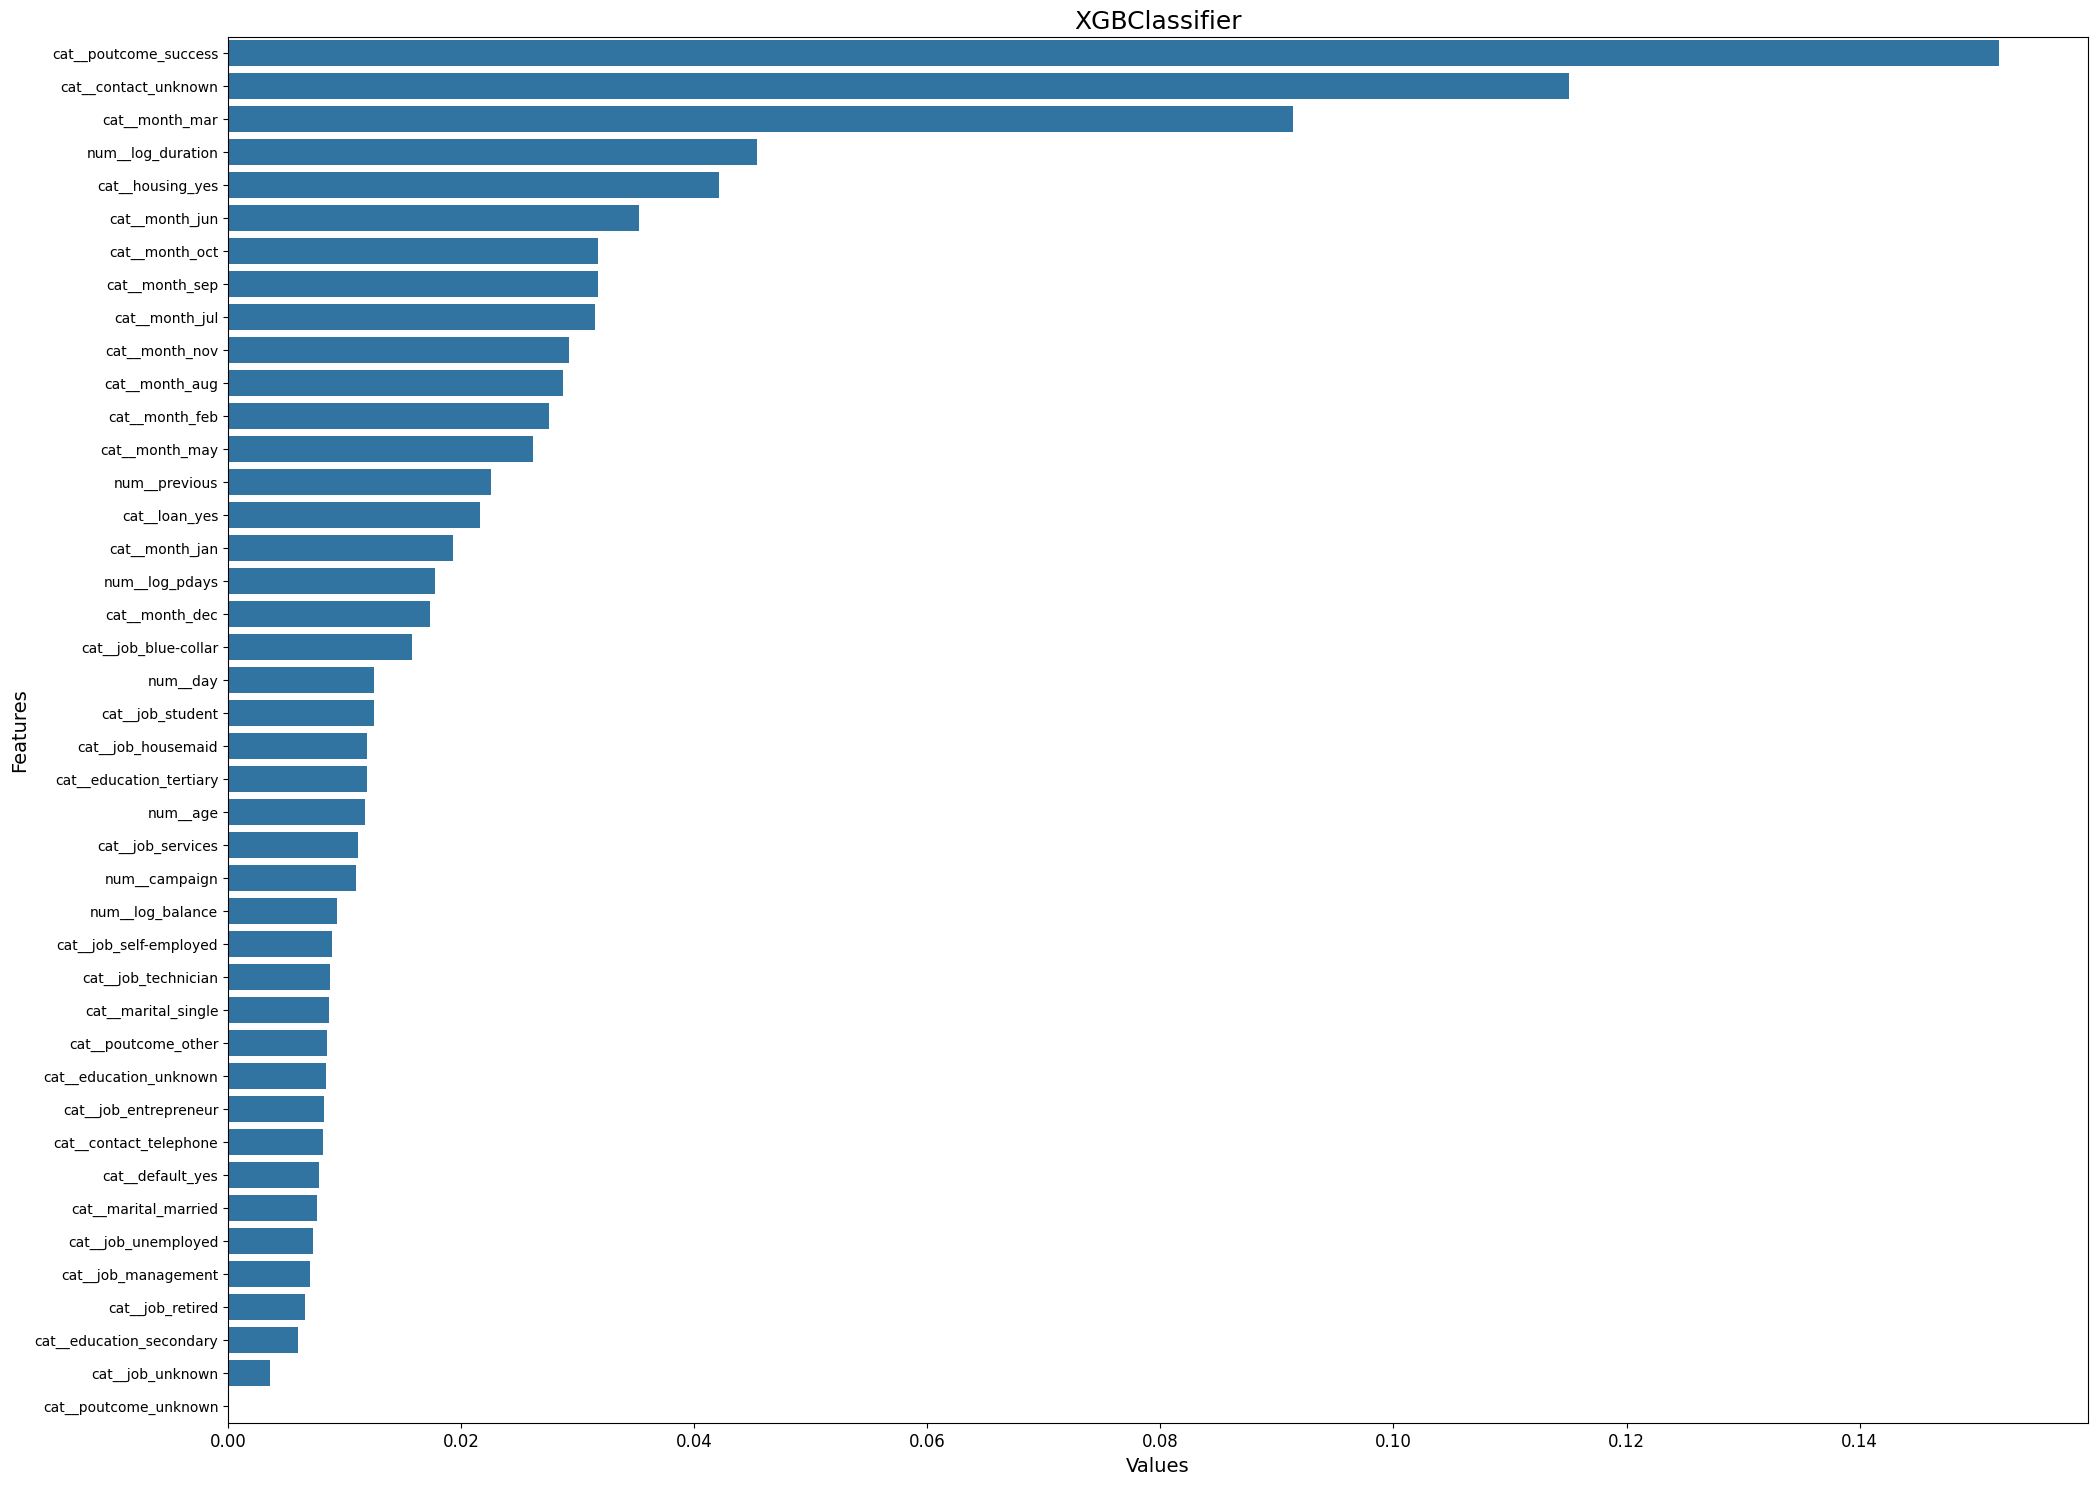

In [17]:
get_feature_importance(list_of_models_log)

## Target Encoding
Target Encoding это способ кодирования категориальных признаков, при котором каждой категории присваивается статистика по целевой переменной. В задаче классификации это вероятность класса. Создадим новые колонки с помощью TargetEncoder по колонкам duration (предварительно проведя бинаризацию), poutcome, education, contact. оригинальные колонки будут удалены из датасета (кроме цифровой колонки duration)

In [3]:
df = data.copy()
# бинаризуем признак duration
duration_bins = [0,250,500,750,1000,1250,1500, 10000]
duration_labels = ['<250', '250-499', '500-749', '750-999', '1000-1249', '1250-1499', '1500+']
df['duration_backet'] = pd.cut(df['duration'], bins=duration_bins, labels = duration_labels)

In [4]:
result_cross_val_te, result_test_te, list_of_models_te = target_enc_pipe(df)

In [6]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val_te)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test_te)
print('')
print('Сравнение полученного результата с baseline')
print('')
display(result_test_te - result_test_baseline)


Результаты на кросс-валидации



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.8994 ± 0.0049,0.8243 ± 0.0071,0.8232 ± 0.0063,0.8012 ± 0.015,0.812 ± 0.0087
RandomForest,0.9178 ± 0.0042,0.8506 ± 0.0044,0.8231 ± 0.0026,0.8721 ± 0.0093,0.8469 ± 0.0051
XGBoost,0.9199 ± 0.0055,0.8513 ± 0.0045,0.8268 ± 0.0019,0.8679 ± 0.0118,0.8468 ± 0.0056



Результаты на тестовой выборке



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.904012,0.825795,0.824442,0.803403,0.813787
RandomForest,0.921398,0.861621,0.830538,0.889414,0.858969
XGBoost,0.926225,0.862965,0.834520,0.886578,0.859762



Сравнение полученного результата с baseline



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,-0.003285,0.000448,-0.003009,0.005671,0.001467
RandomForest,0.002069,0.000000,-0.001171,0.001890,0.000258
XGBoost,0.000499,-0.001343,-0.006492,0.006616,-0.000285


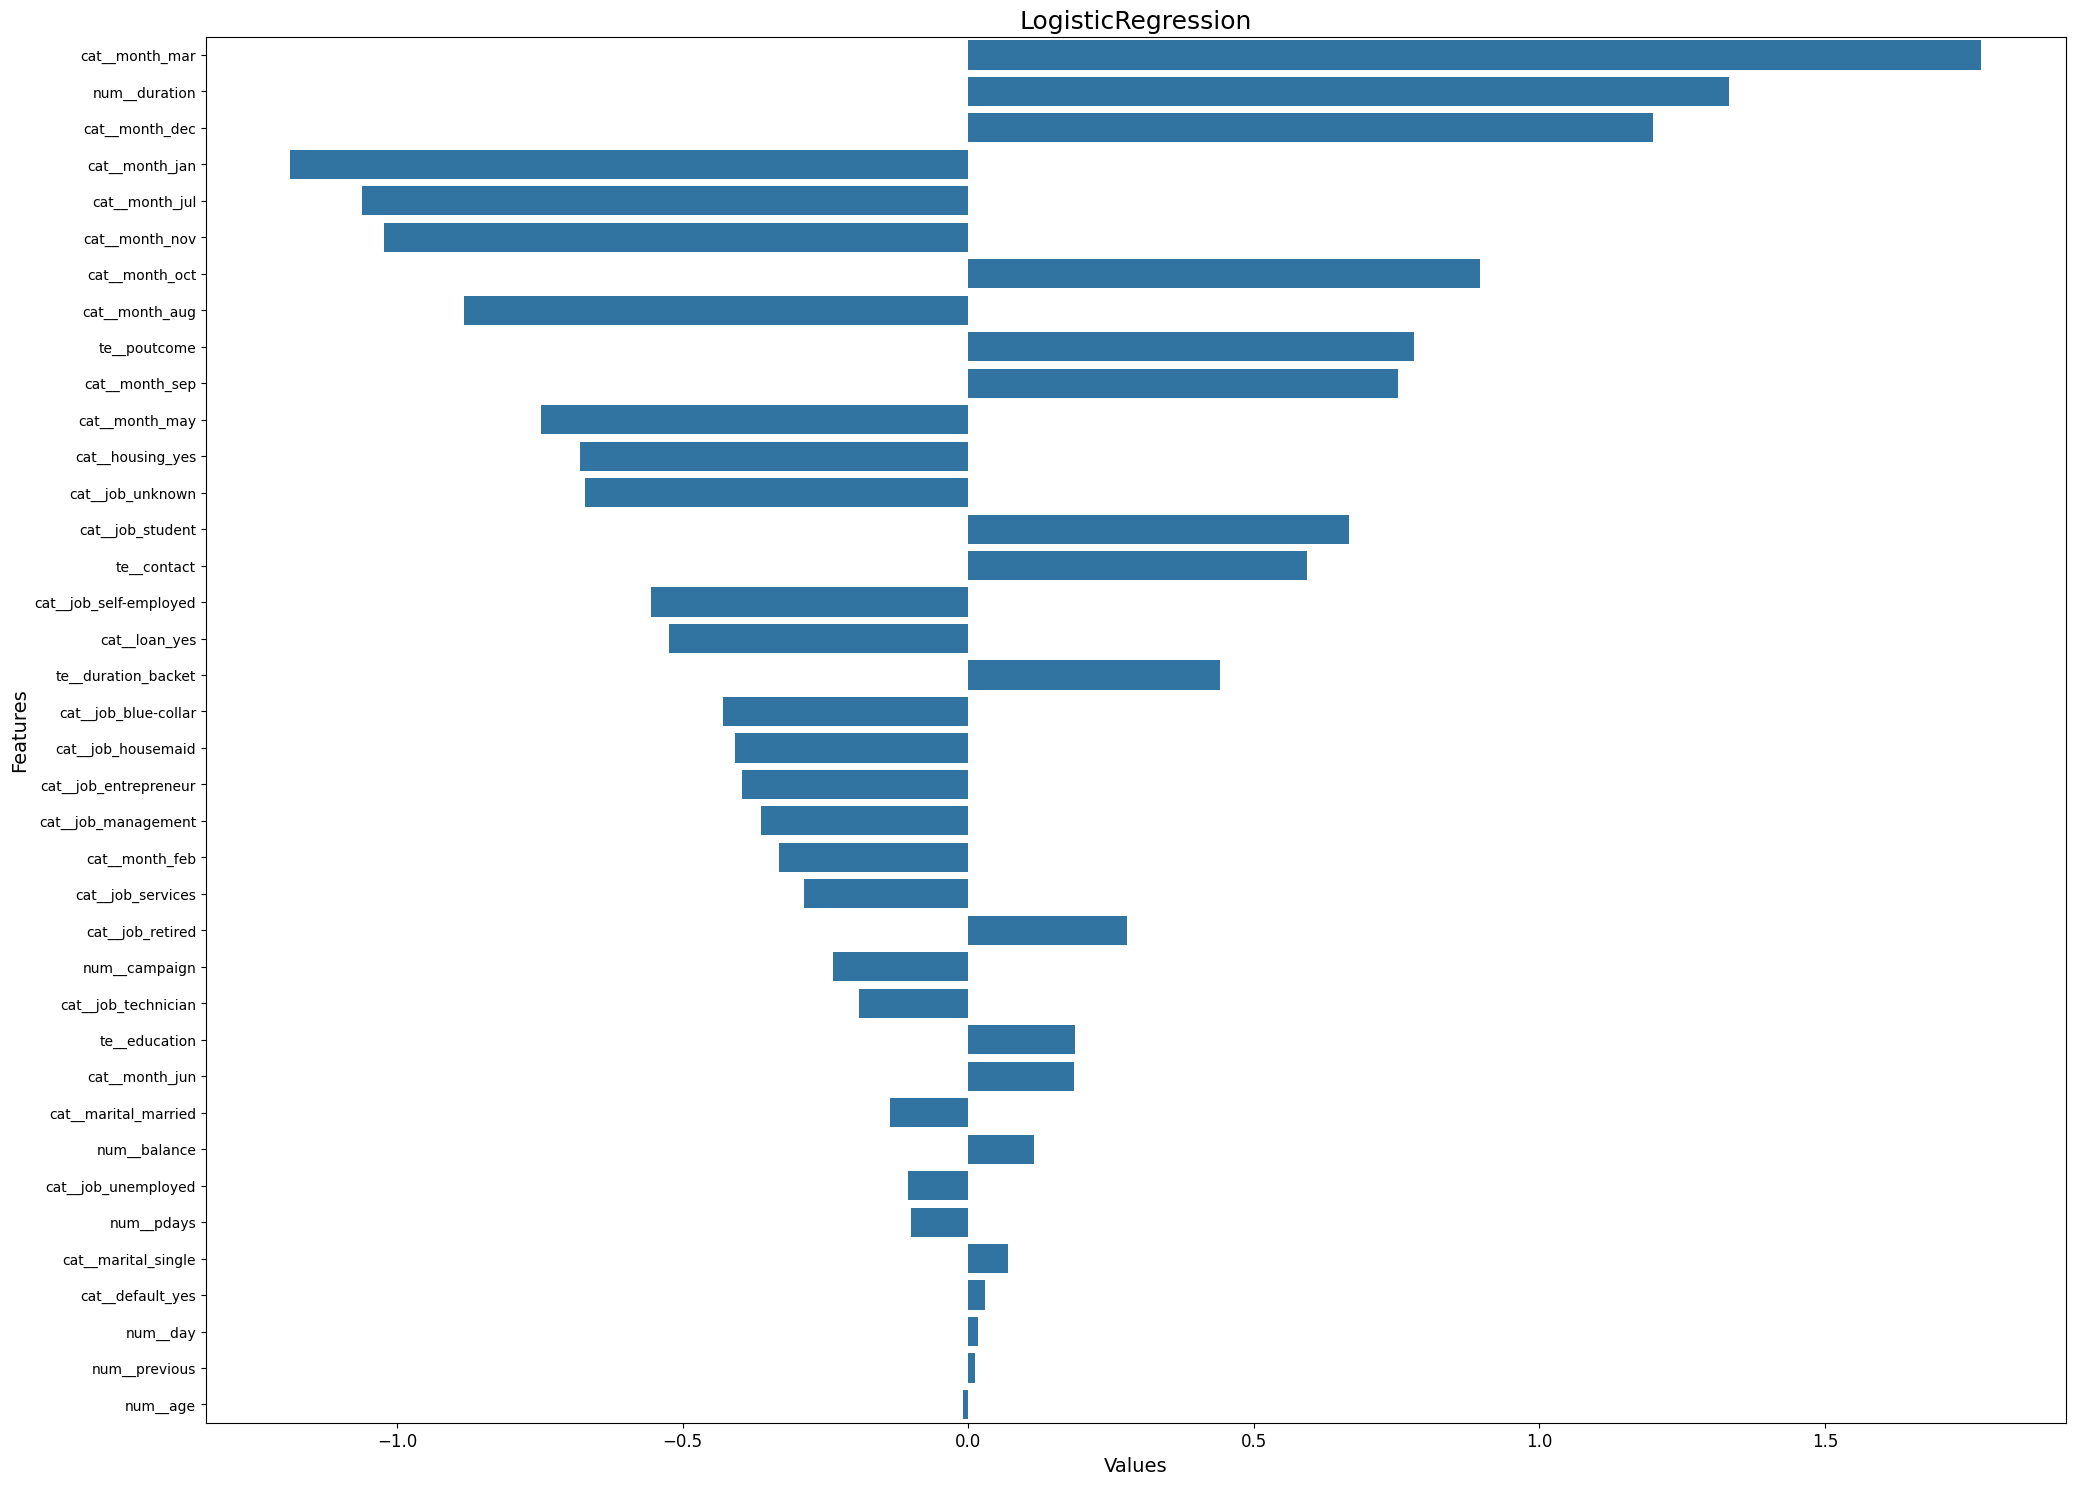

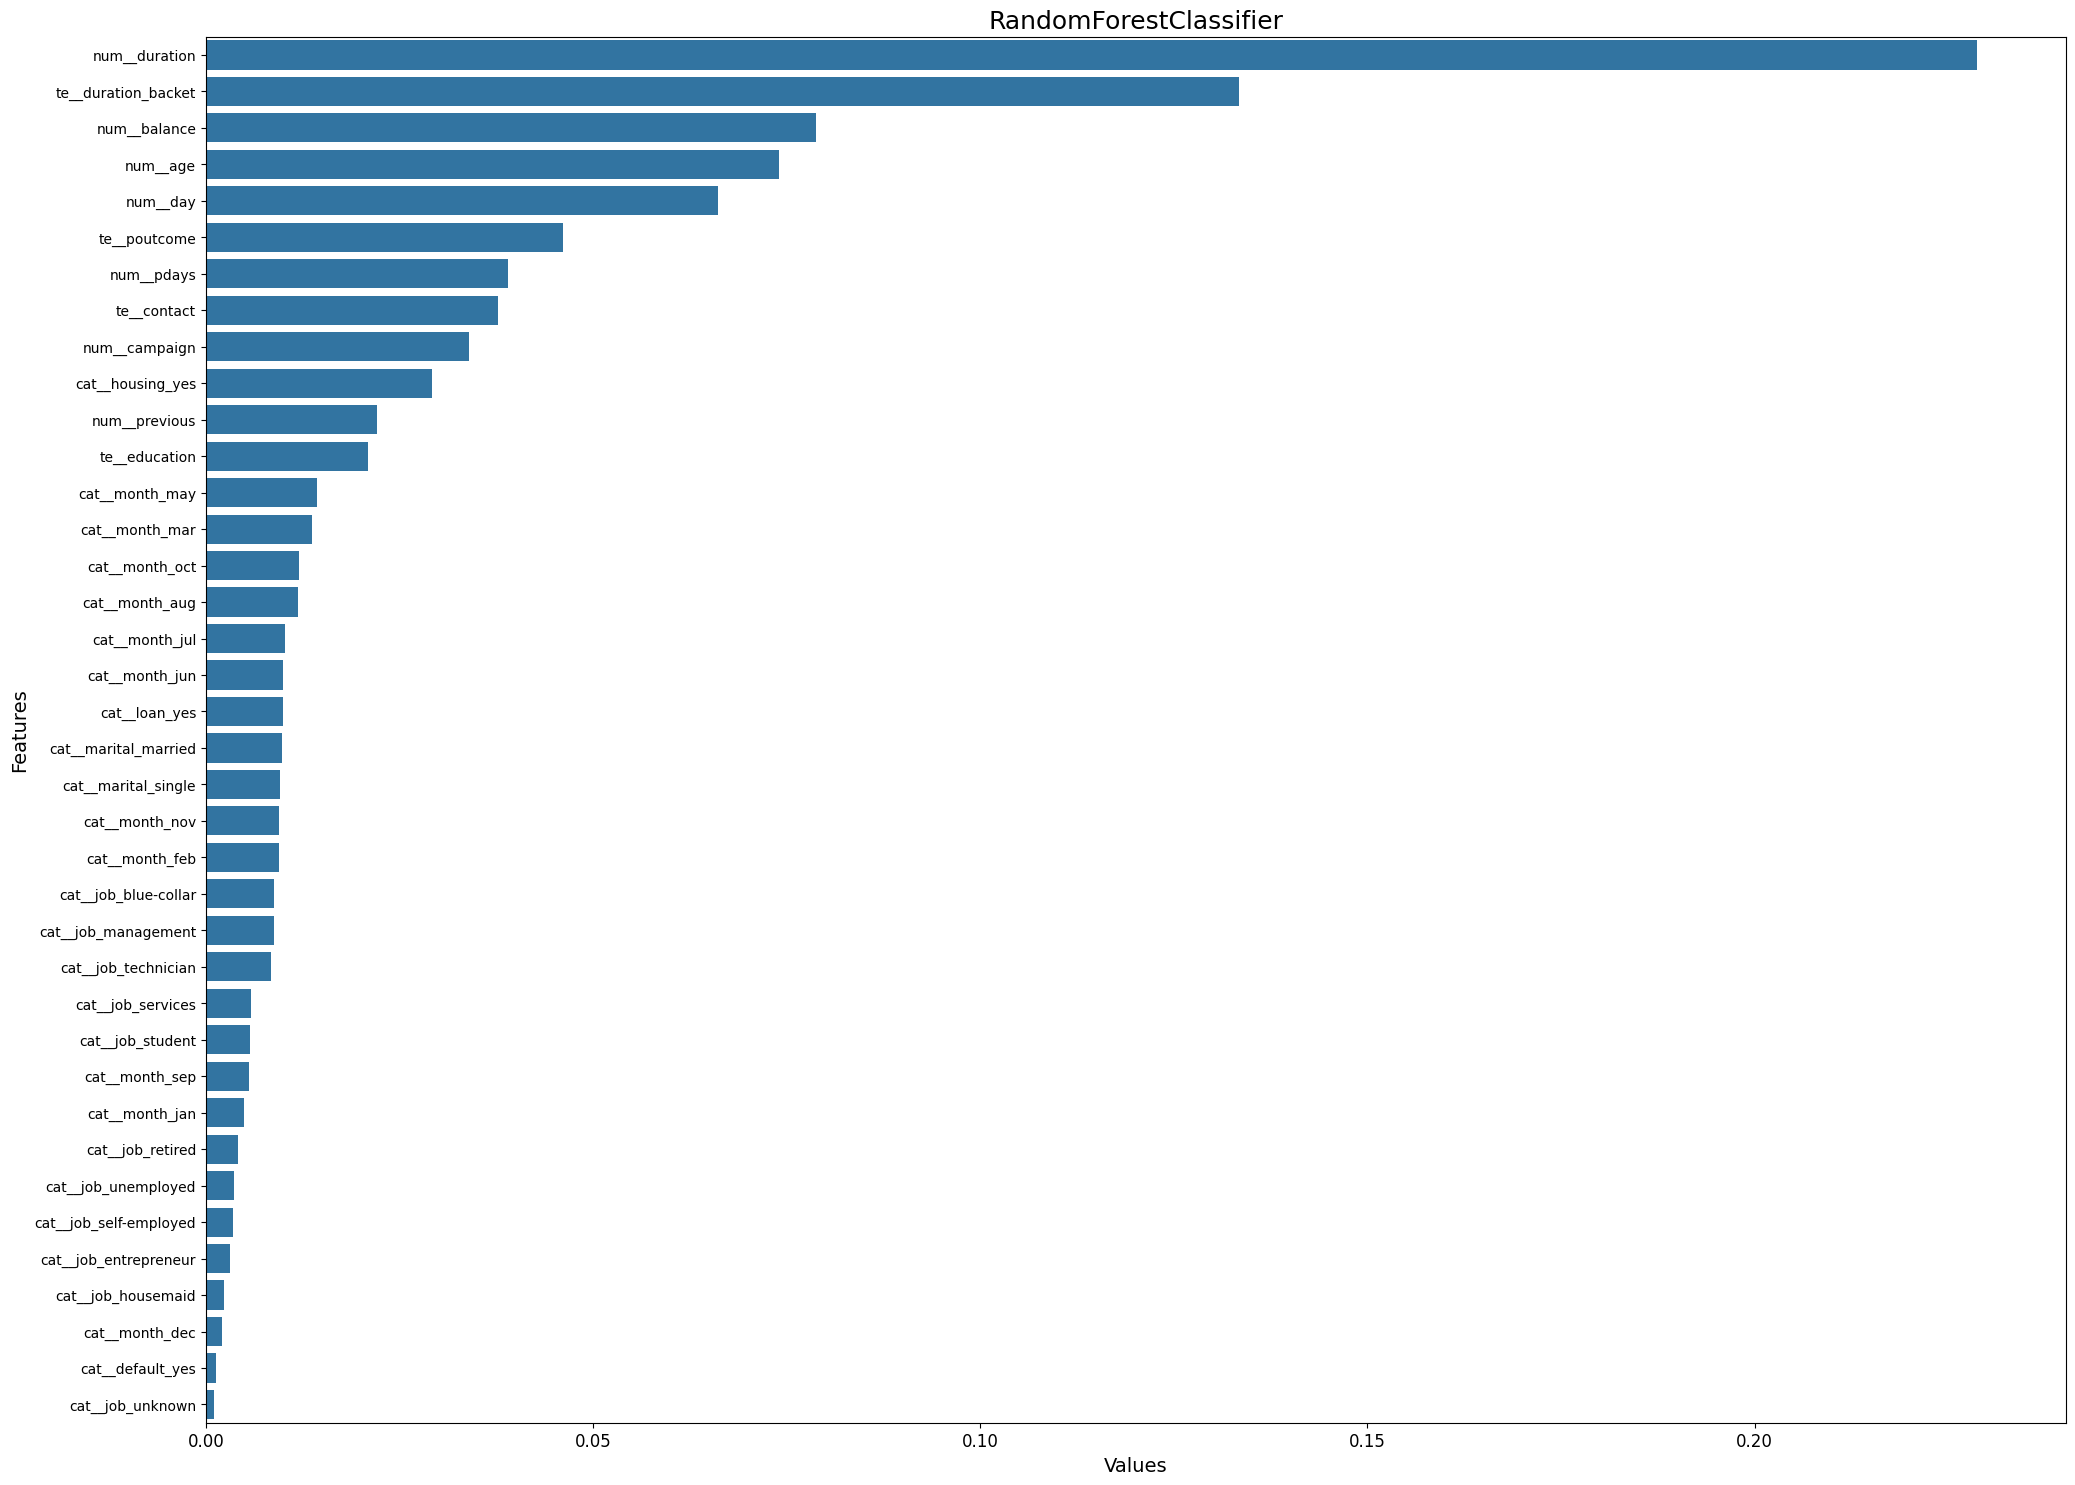

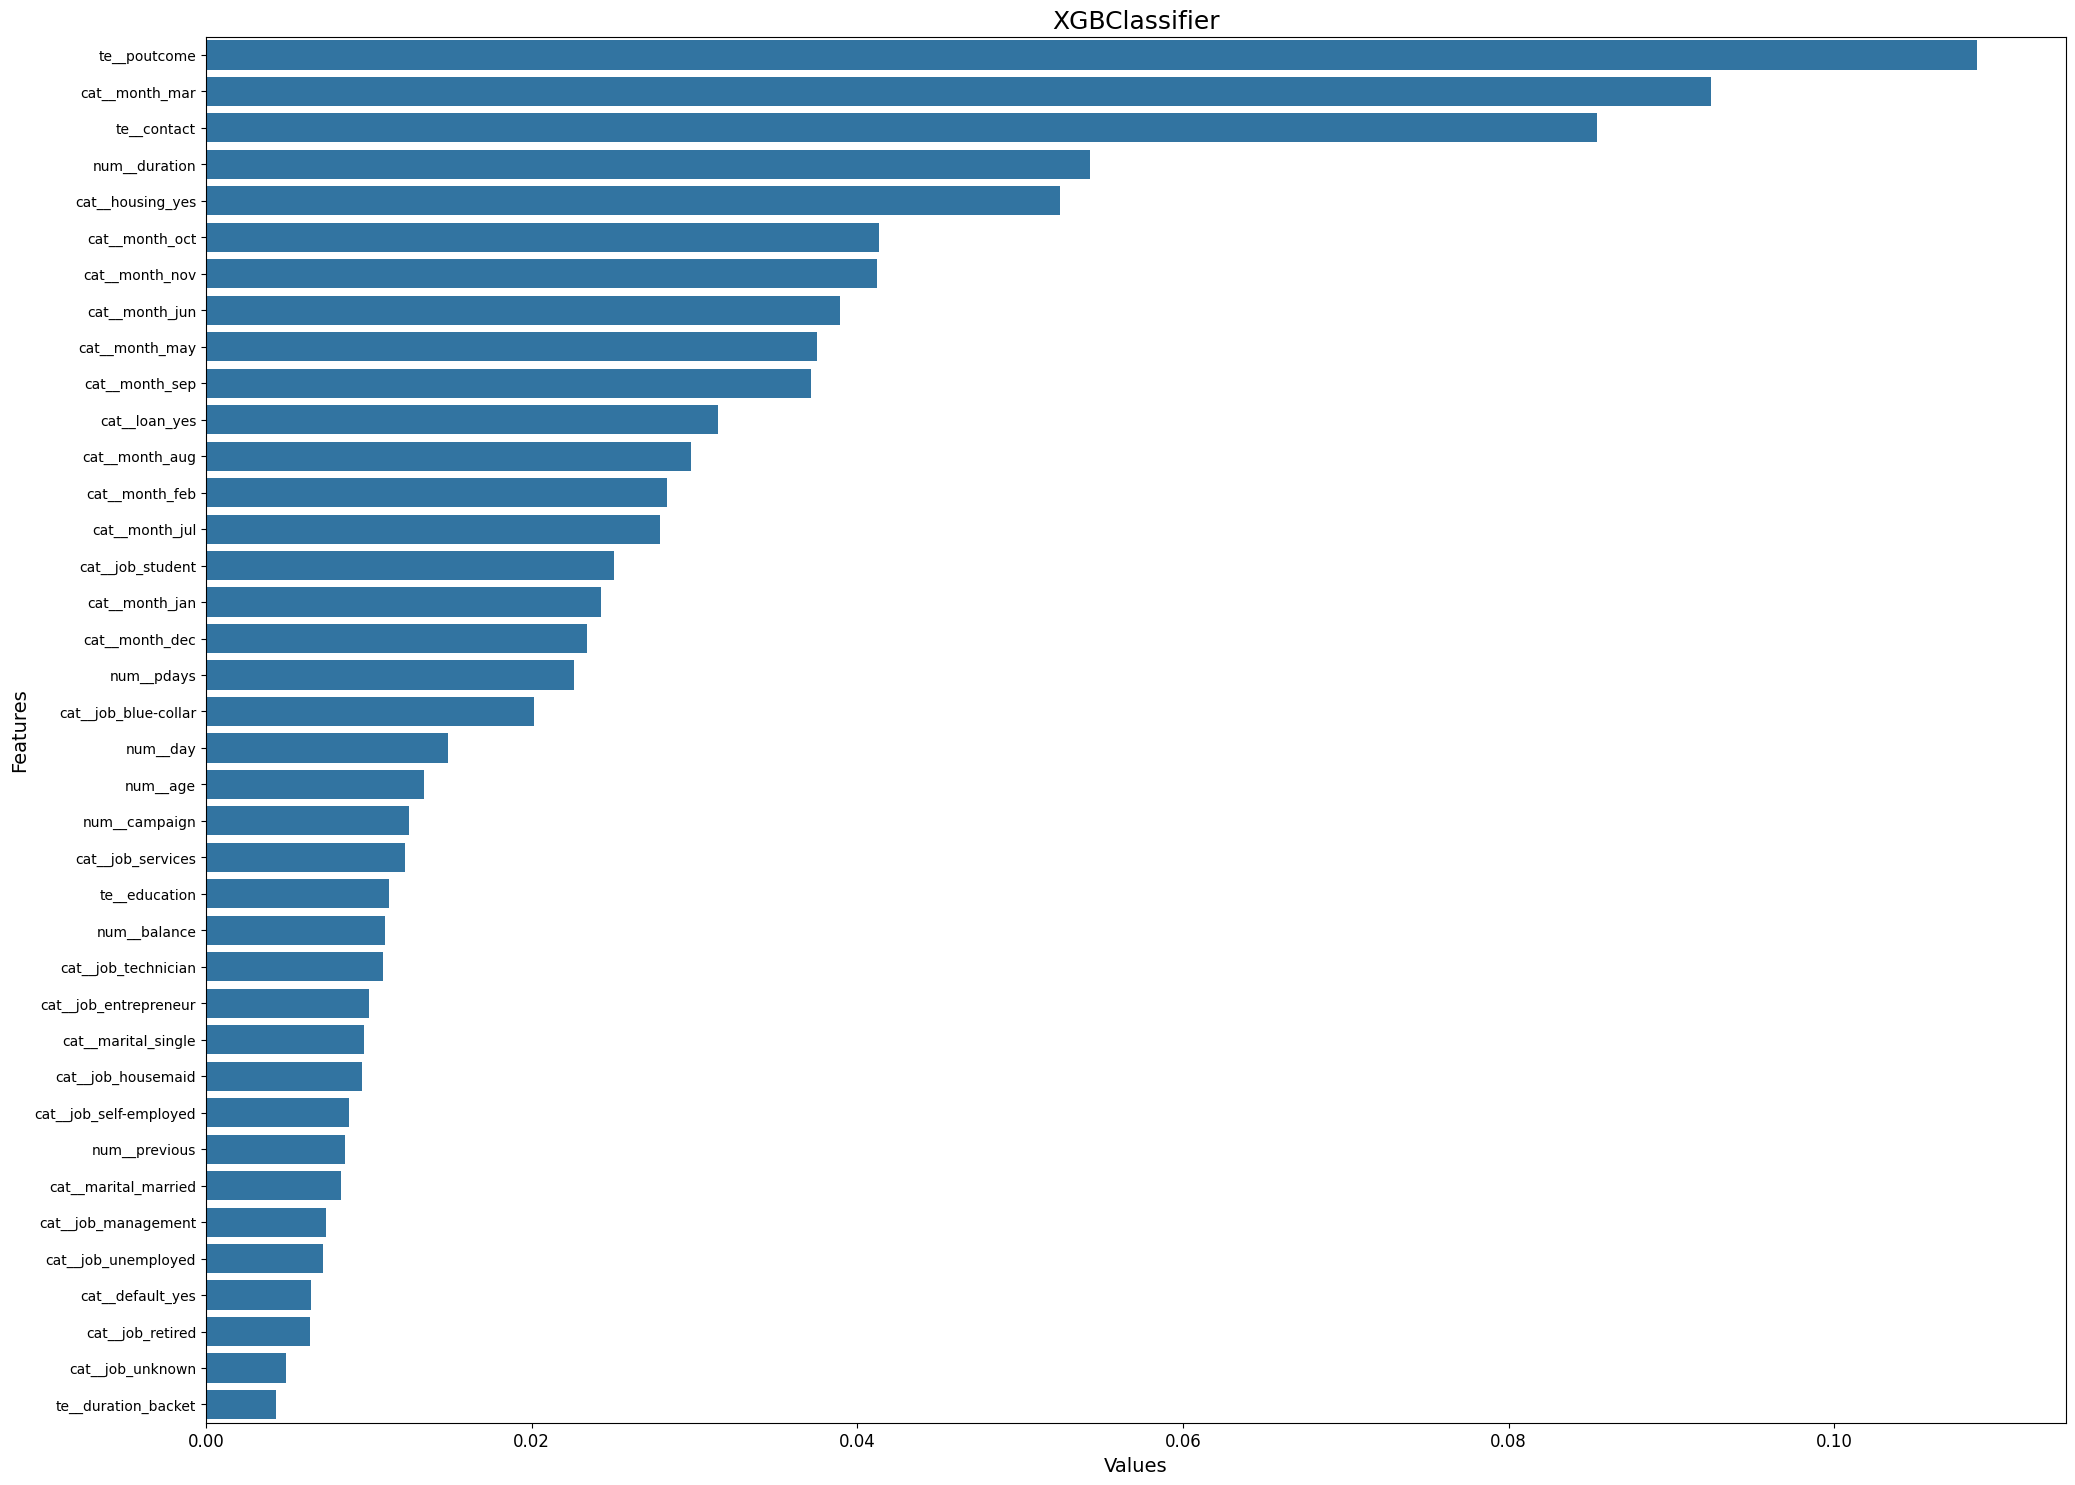

In [6]:
get_feature_importance(list_of_models_te)

## Обработка выбросов
Так как в датасете присутствуют выбросы попробуем заменить их экстремальные значения на 1-ый или 99-ый квантиль

In [11]:
df = data.copy()

In [12]:
result_cross_val_o, result_test_o, list_of_models_o = outliers_pipe(df)

In [13]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val_o)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test_o)
print('')
print('Сравнение полученного результата с baseline')
print('')
display(result_test_o - result_test_baseline)


Результаты на кросс-валидации



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.9021 ± 0.0045,0.8252 ± 0.008,0.8293 ± 0.0059,0.7946 ± 0.0189,0.8115 ± 0.0102
RandomForest,0.9171 ± 0.0039,0.8499 ± 0.0056,0.8199 ± 0.0037,0.8757 ± 0.011,0.8468 ± 0.0064
XGBoost,0.9205 ± 0.0042,0.8514 ± 0.0031,0.8262 ± 0.0035,0.8693 ± 0.0101,0.8471 ± 0.0041



Результаты на тестовой выборке



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.907356,0.825795,0.827620,0.798677,0.812891
RandomForest,0.919770,0.861173,0.827496,0.893195,0.859091
XGBoost,0.927481,0.867443,0.840787,0.888469,0.863971



Сравнение полученного результата с baseline



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.000060,0.000448,0.000169,0.000945,0.000571
RandomForest,0.000442,-0.000448,-0.004214,0.005671,0.000380
XGBoost,0.001754,0.003135,-0.000225,0.008507,0.003924


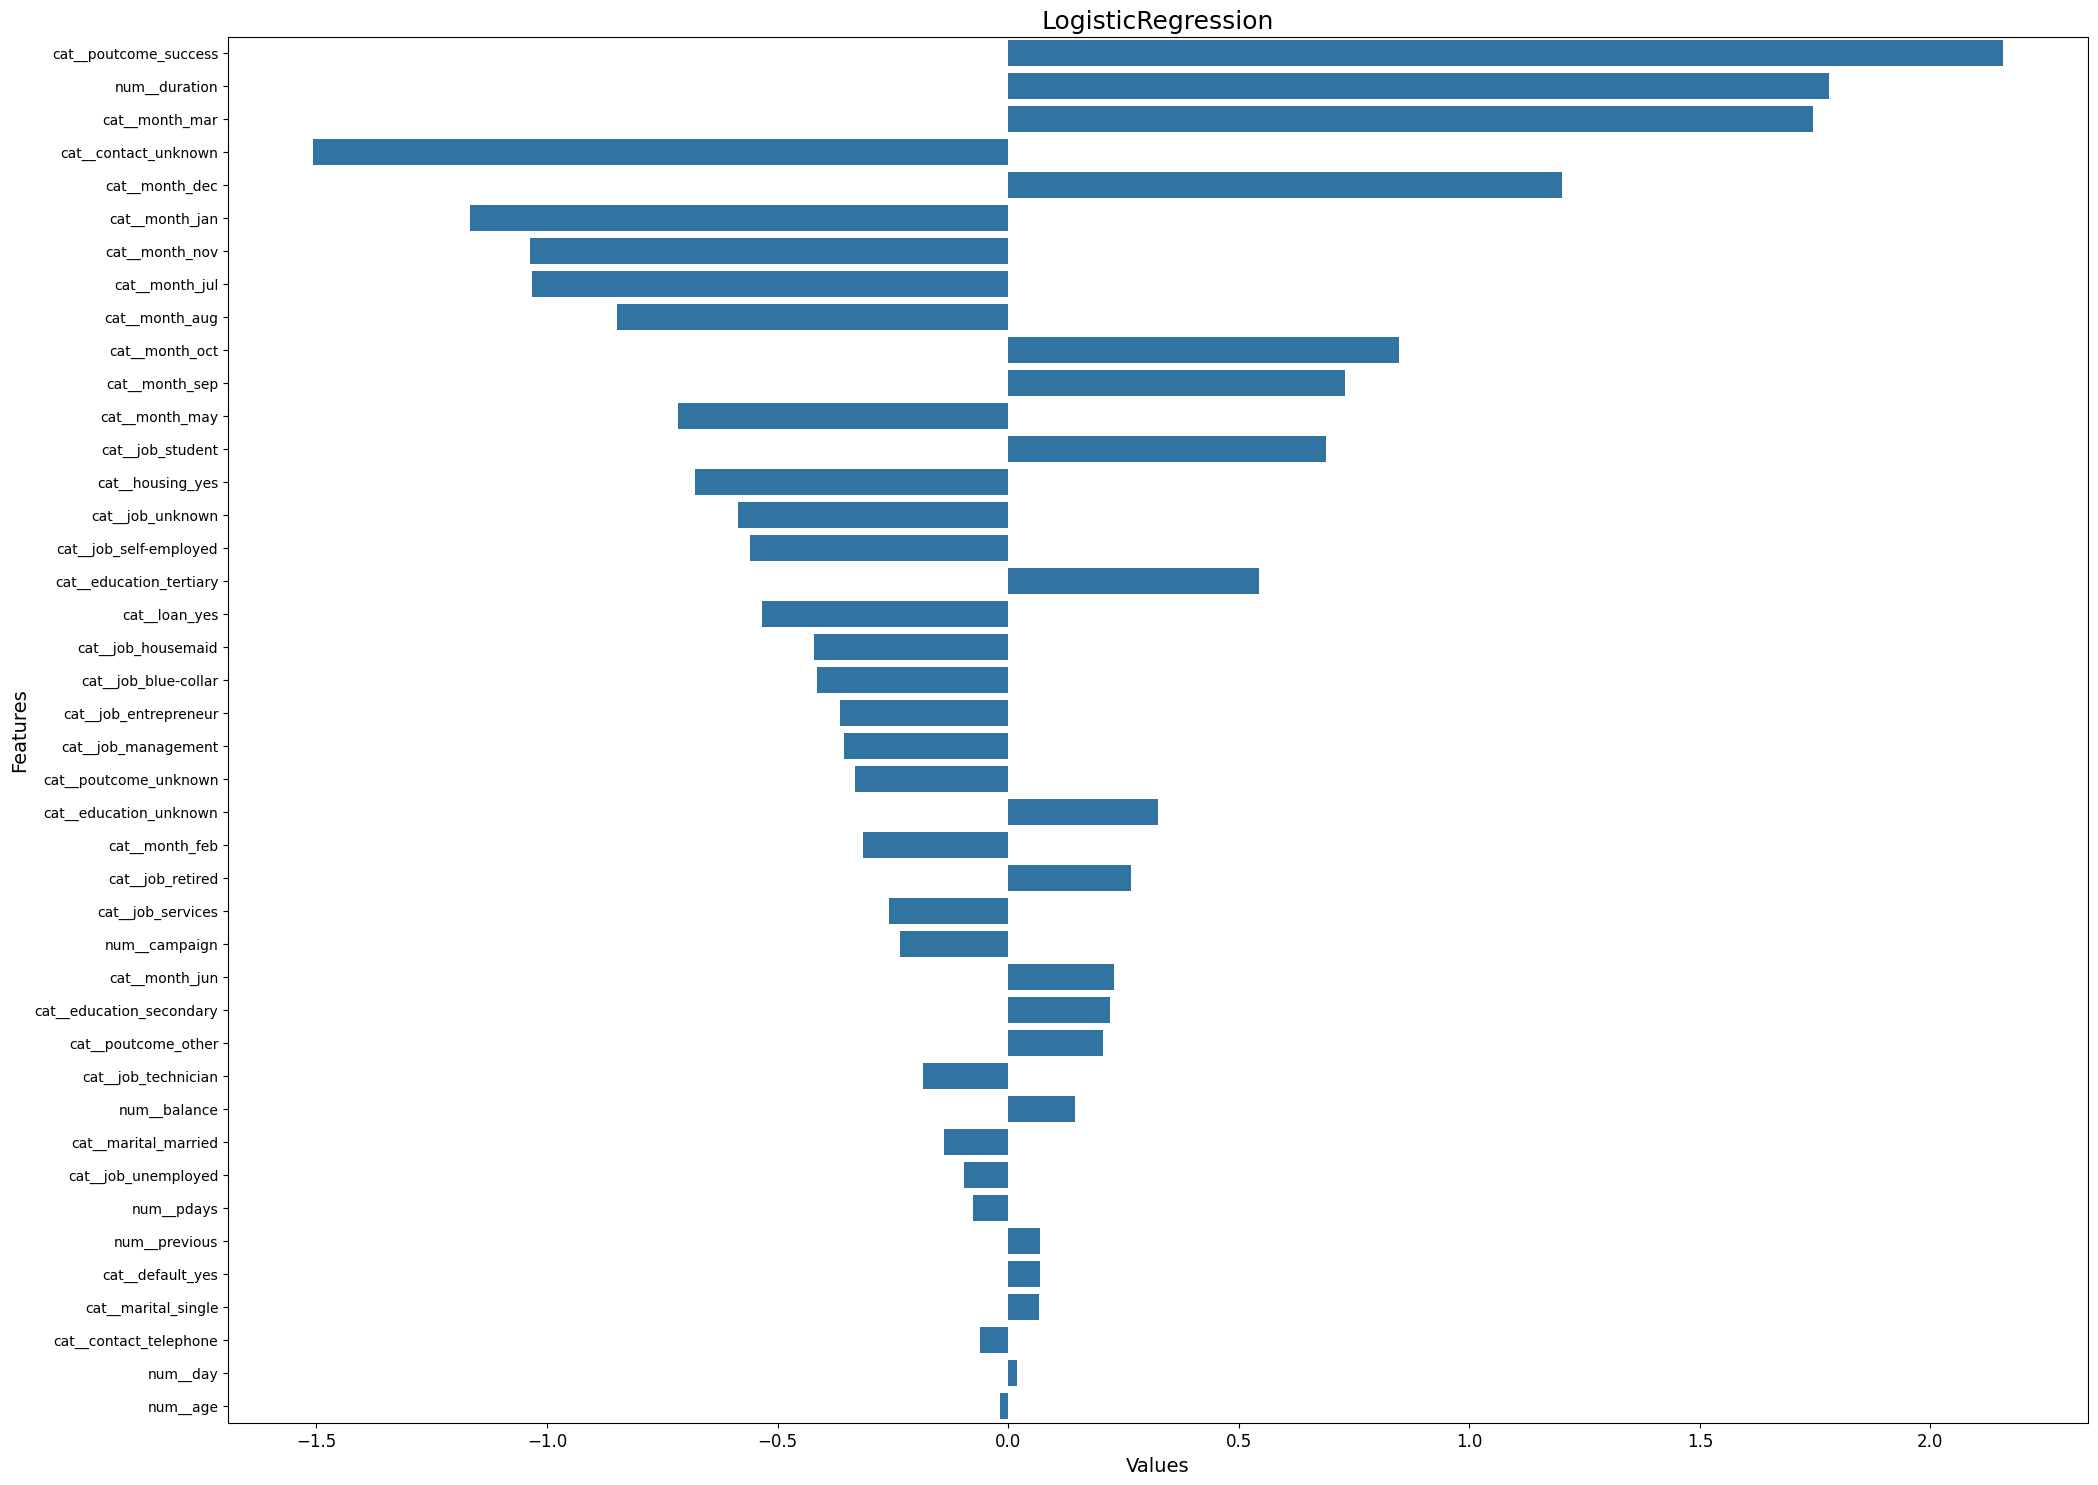

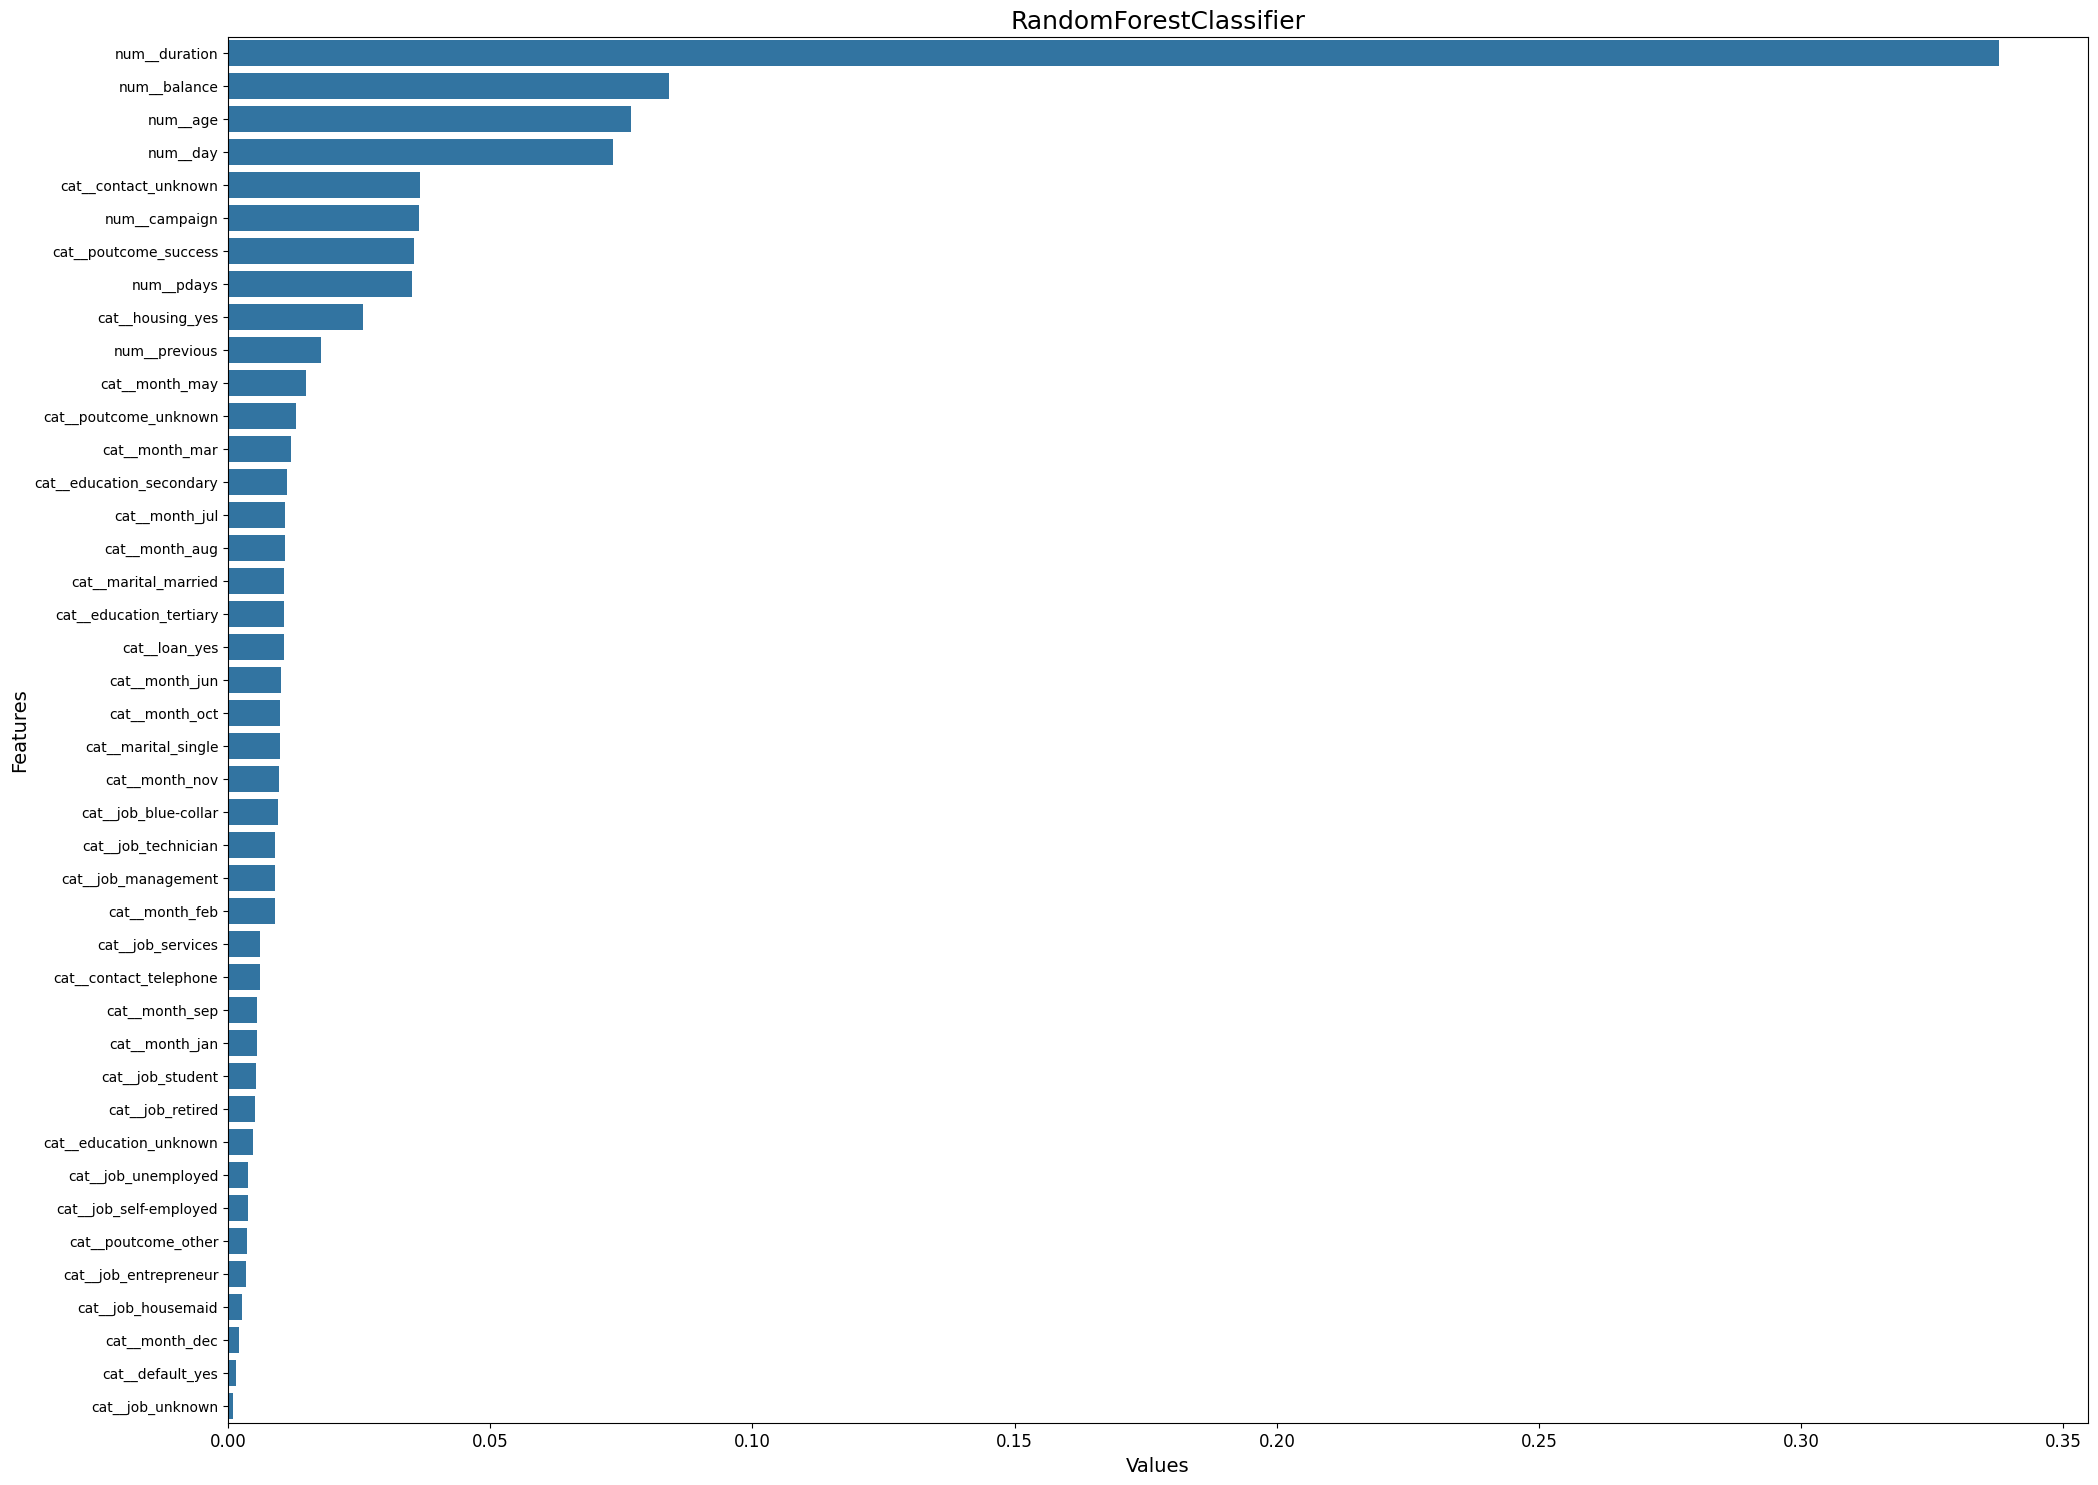

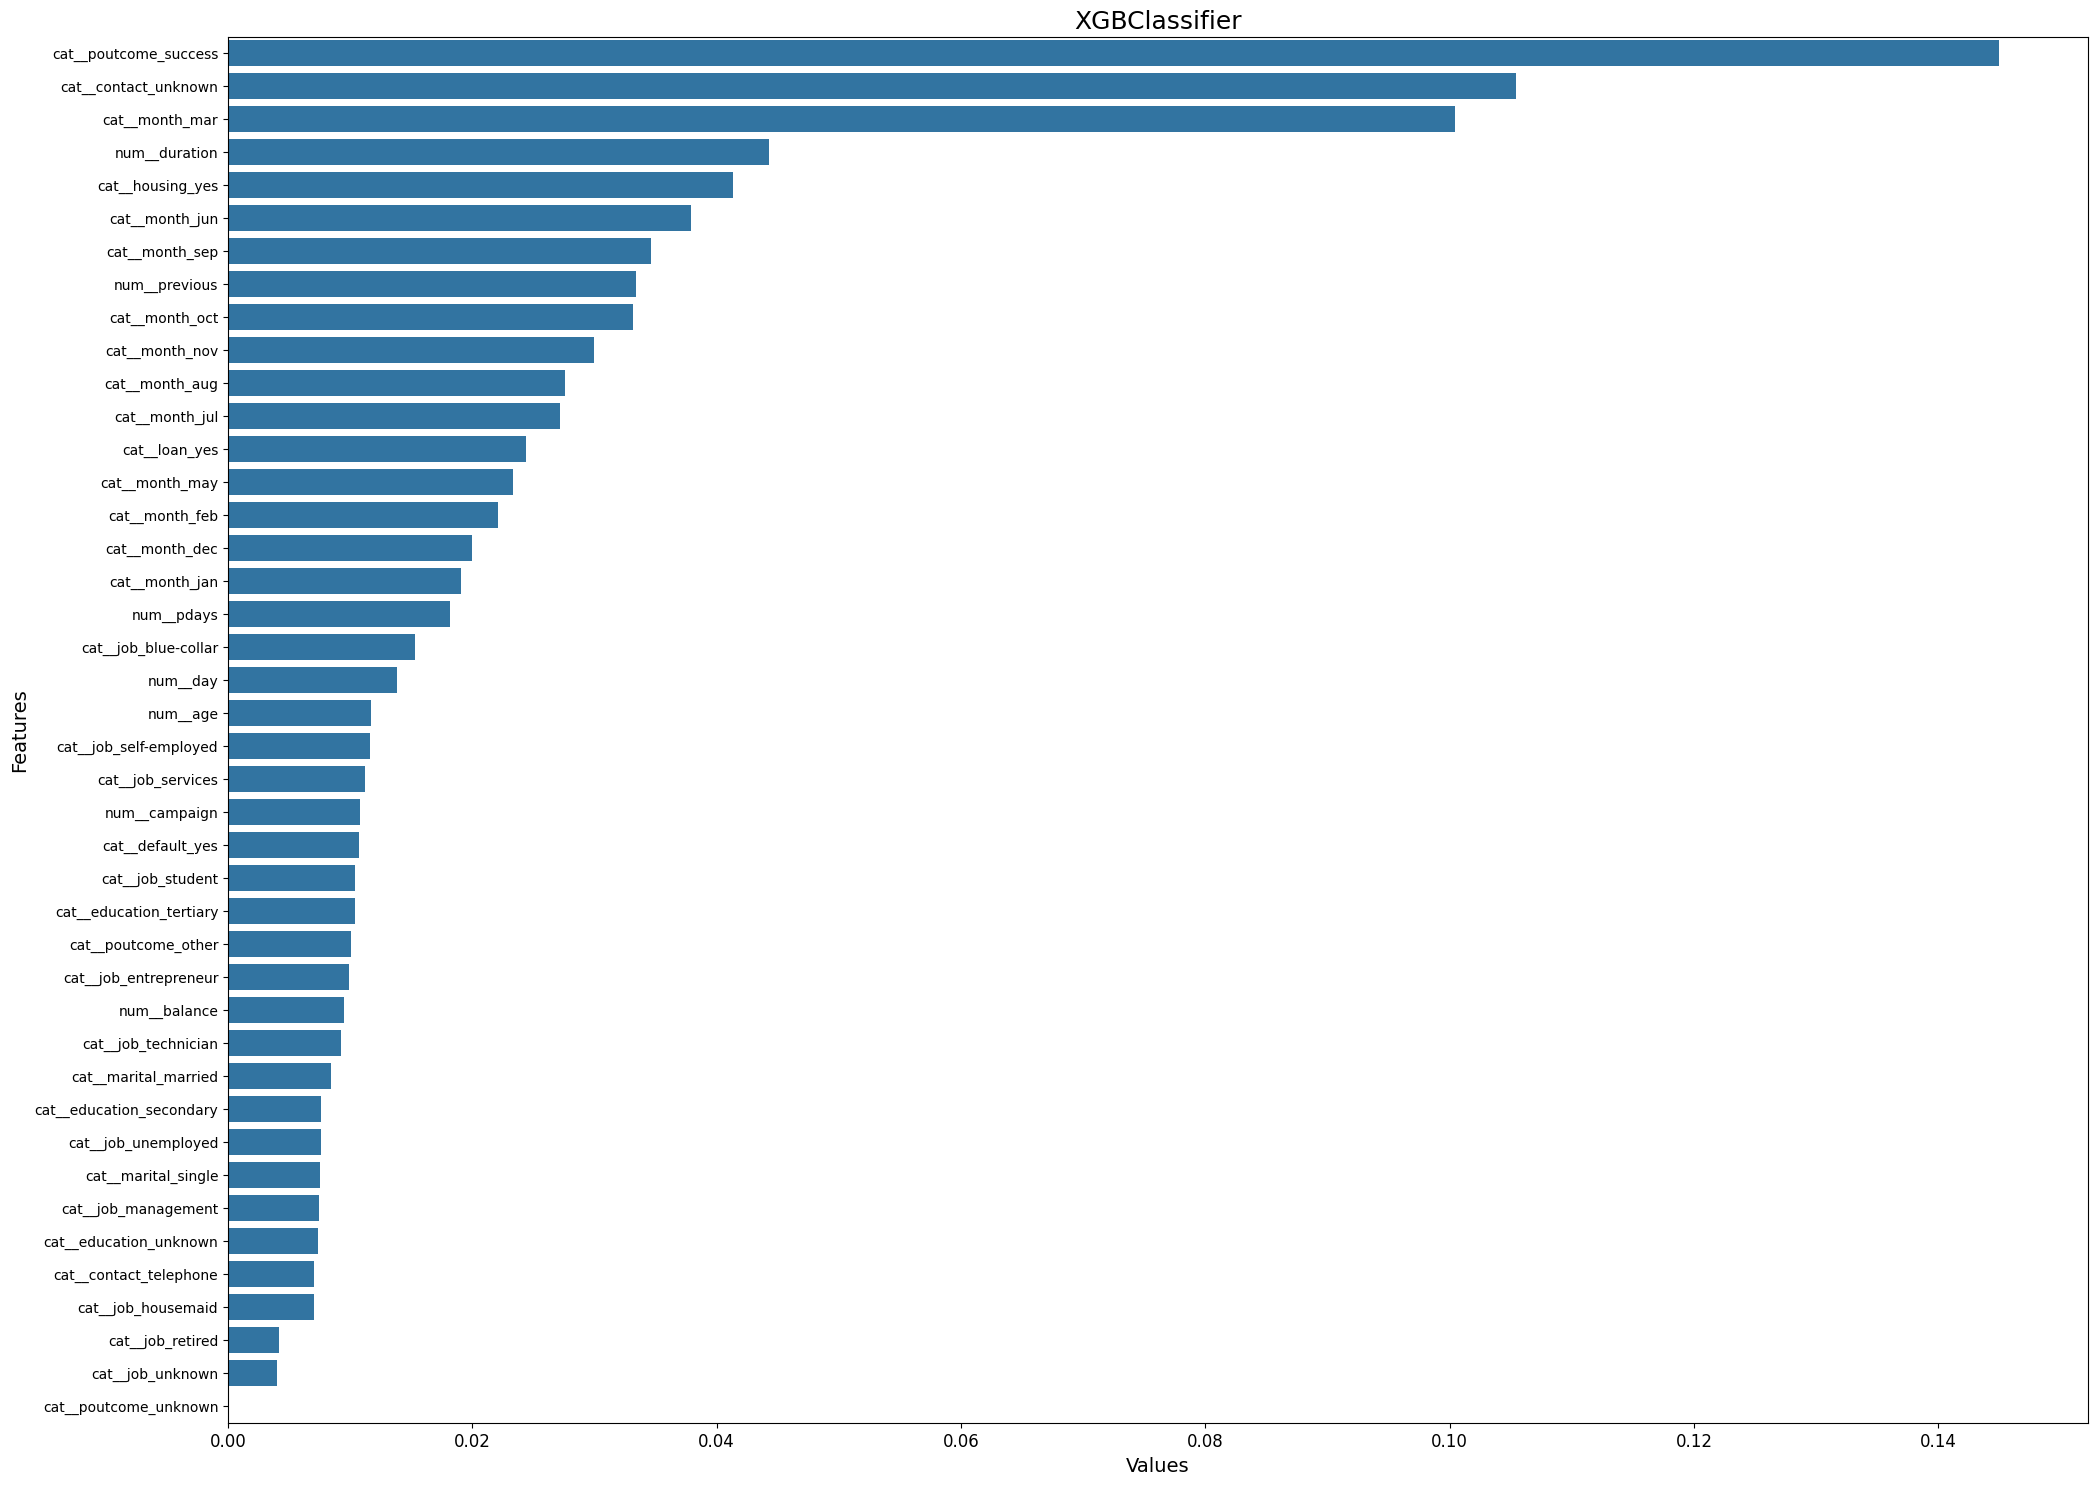

In [12]:
get_feature_importance(list_of_models_o)

## ИТОГИ

По результатм обучения моделей можно сделать вывод, что явного явного увеличения метрик не наблюдается.
При этом не забываем, что мы строим модели для привлечения клиентов на размещение депозитов в банк. В данной задаче важнее метрика recall - цена ошибки "пропустить" клиента, который готов оформить депозит выше, чем позвонить лишнему клиенту. Т.е. будем считать, что доход от размещения депозита гораздо выше, чем затраты на звонок клиенту. Поэтому если ориентироваться на метрику recall, то наилучшие показатели показали модели при обработке выбросов. Их и возьмем для улучшения метрик в рамках следующего шага - hyper_param_tuning.